因为黄金在25-26年的热潮,紫金矿业变成了散户聚集的地方.一个观点认为,紫金矿业是跟金,但是他的主营业务也慢慢加入了铜,与锂等矿产.  
我们放弃了时间维度,保留金铜的相对变化.我们单独拆开,看看只保留黄金,铜,两者加起来,保留5日相对变化率和20日相对变化率的效果.

之后,我们再看更换激活函数以后,是否会有所改善,我并不确定相应开关突变是否更适合股价预测.

# 实验设置：去掉时间，拆分金铜涨幅，再比较激活函数

保留原7个水平变量（包括金价、铜价），仅改变新增的涨幅特征。“只保留黄金”在本实验指只新增黄金涨幅，不删除原有铜价等基准变量。10组输入 × ReLU/sigmoid = 20个模型；先看ReLU特征对照，再看相同输入下更换激活函数。

| 编号 | 新增涨幅 | 总输入数 |
|---|---|---:|
| 01 | 无：基准 | 7 |
| 02 | 金5日 | 8 |
| 03 | 金20日 | 8 |
| 04 | 金5＋20日 | 9 |
| 05 | 铜5日 | 8 |
| 06 | 铜20日 | 8 |
| 07 | 铜5＋20日 | 9 |
| 08 | 金铜均5日 | 9 |
| 09 | 金铜均20日 | 9 |
| 10 | 金铜均5＋20日 | 11 |

“日”沿用06的口径：按对齐数据向前5/20条记录，累计变化率 = 当前值/滞后值−1，不是自然日或平均每日涨幅。所有组删除相同的前20行，确保训练和测试日期一致；没有时间输入。使用Dataset.pkl原始同日目标，不宣称为可交易的未来预测。

训练集：2026年以前所有共同样本；测试集：2026年现有样本。隐藏层16/32、线性输出、Adam、学习率0.01、全批量、固定种子42。输入和目标的标准化只拟合训练集。不同输入维度的同种子初始化不完全相同；本次为单种子探索。

主比较统一采用100轮权重和MAPE。另延长至1000轮仅作训练收敛诊断，保存100轮模型，不用2026年误差选择轮数。下降趋缓不等于达到全局最优；若100轮不足，应明确报告，后续用2026年以前的时间验证段选轮数。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_OUT',str(ROOT/'results/mlp_activation_features_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}
tr=x.index[x.index.year<2026];te=x.index[x.index.year==2026]
assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all()
splits=pd.DataFrame([{'Split':s,'N':len(idx),'Start':idx.min(),'End':idx.max()} for s,idx in [('Train',tr),('Test',te)]])
display(splits);splits.to_csv(OUT/'splits.csv',index=False)
config={'seed':SEED,'lr':LR,'main_epochs':MAIN_EPOCHS,'diagnostic_epochs':DIAG_EPOCHS,'base':BASE,'extras':EXTRAS,
'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
sy=StandardScaler().fit(y.loc[tr].to_numpy().reshape(-1,1))
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
yt=tensor(sy.transform(y.loc[tr].to_numpy().reshape(-1,1)))

,Split,N,Start,End
0,Train,3665,2012-06-06,2025-12-31
1,Test,152,2026-01-01,2026-07-23


## 1. 训练全部模型并保留100轮权重
MSE曲线记录每轮更新后的训练损失。标准化目标在所有组完全一致，因此标准化MSE可以直接比较；同时保存原股价单位平方的MSE。第101—1000轮的模型不用于主测试排名。

In [2]:
histories,metric_rows,pred_frames,diag_rows=[],[],[],[]
for activation in ['ReLU','Sigmoid']:
    for name,extra in EXTRAS.items():
        cols=BASE+extra
        sx=StandardScaler().fit(x.loc[tr,cols])
        xt=tensor(sx.transform(x.loc[tr,cols]))
        torch.manual_seed(SEED)
        act=nn.ReLU if activation=='ReLU' else nn.Sigmoid
        model=nn.Sequential(nn.Linear(len(cols),16),act(),nn.Linear(16,32),act(),nn.Linear(32,1))
        opt=torch.optim.Adam(model.parameters(),lr=LR)
        losses=[]
        for epoch in range(1,DIAG_EPOCHS+1):
            model.train();opt.zero_grad()
            loss=((model(xt)-yt)**2).mean()
            assert torch.isfinite(loss)
            loss.backward();opt.step()
            model.eval()
            with torch.no_grad(): current=((model(xt)-yt)**2).mean().item()
            assert np.isfinite(current)
            losses.append(current)
            if epoch==MAIN_EPOCHS:state100=deepcopy(model.state_dict())
        histories.append(pd.DataFrame({'Activation':activation,'Model':name,'Epoch':np.arange(1,DIAG_EPOCHS+1),
             'MSE_standardized':losses,'MSE_original':np.array(losses)*sy.scale_[0]**2}))
        # 只回到100轮模型后才计算MAPE。
        model.load_state_dict(state100)
        for split,idx in [('Train',tr),('Test',te)]:
            with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,cols]))).numpy()).ravel()
            truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            assert np.isfinite(pred).all()
            metric_rows.append({'Activation':activation,'Model':name,'Inputs':len(cols),'Split':split,'Epochs':100,
                 'N':len(idx),'MAPE':np.abs(pe).mean(),'MPE':pe.mean()})
            pred_frames.append(pd.DataFrame({'Date':idx,'Activation':activation,'Model':name,'Split':split,
                'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
        l=np.array(losses);best_after=l[100:].min();improve=100*(l[99]-best_after)/max(l[99],1e-12)
        diag_rows.append({'Activation':activation,'Model':name,'MSE_80':l[79],'MSE_100':l[99],
            'MSE_200':l[199],'MSE_500':l[499],'MSE_1000':l[999],
            'Change_80_to_100_percent':100*(l[79]-l[99])/max(l[79],1e-12),
            'Best_MSE_101_1000':best_after,'Best_epoch_101_1000':int(np.argmin(l[100:])+101),
            'Further_reduction_percent':improve,
            'Plateau_under_1pct_rule':bool(improve<1)})
        torch.save({'state_dict_100':state100,'features':cols,'activation':activation,'seed':SEED,'epochs':100,
            'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},
            OUT/f'{activation}_{name}_epoch100.pt')
        print(activation,name,'完成',flush=True)
history=pd.concat(histories,ignore_index=True);metrics=pd.DataFrame(metric_rows)
predictions=pd.concat(pred_frames,ignore_index=True);diagnostics=pd.DataFrame(diag_rows)
for name,df in [('training_history',history),('metrics_epoch100',metrics),('predictions_epoch100',predictions),('convergence_diagnostics',diagnostics)]:
    df.to_csv(OUT/f'{name}.csv',index=False)
print('全部完成：20个模型；100轮评价与1000轮训练诊断分开。')

ReLU 01_base 完成
ReLU 02_gold5 完成
ReLU 03_gold20 完成
ReLU 04_gold5_20 完成
ReLU 05_copper5 完成
ReLU 06_copper20 完成
ReLU 07_copper5_20 完成
ReLU 08_both5 完成
ReLU 09_both20 完成
ReLU 10_both5_20 完成
Sigmoid 01_base 完成
Sigmoid 02_gold5 完成
Sigmoid 03_gold20 完成
Sigmoid 04_gold5_20 完成
Sigmoid 05_copper5 完成
Sigmoid 06_copper20 完成
Sigmoid 07_copper5_20 完成
Sigmoid 08_both5 完成
Sigmoid 09_both20 完成
Sigmoid 10_both5_20 完成
全部完成：20个模型；100轮评价与1000轮训练诊断分开。


## 2. 每个模型的训练MSE：前100轮与延长训练
每个面板对应一种输入组合，蓝色ReLU、橙色sigmoid；两种激活函数都替换全部隐藏层，输出层保持线性。纵轴使用对数刻度，便于看清训练后段变化。

延长训练后的最小训练MSE仅用于检查100轮之后还能下降多少，不是根据测试集选出的最佳模型。

20/20个模型在101—1000轮至少还有1%的训练MSE下降空间。
1%只是明确的诊断阈值，不是收敛证明；低于阈值也不证明达到最优。


,Activation,Model,MSE_80,MSE_100,MSE_200,MSE_500,MSE_1000,Change_80_to_100_percent,Best_MSE_101_1000,Best_epoch_101_1000,Further_reduction_percent,Plateau_under_1pct_rule
0,ReLU,01_base,0.01360,0.00994,0.00505,0.00368,0.00273,26.85880,0.00272,994,72.67327,False
1,ReLU,02_gold5,0.02842,0.02047,0.00659,0.00365,0.00262,27.98847,0.00262,1000,87.18775,False
2,ReLU,03_gold20,0.02702,0.01975,0.00671,0.00357,0.00270,26.89321,0.00264,992,86.62029,False
3,ReLU,04_gold5_20,0.01412,0.00893,0.00550,0.00352,0.00222,36.76422,0.00210,988,76.51949,False
4,ReLU,05_copper5,0.02406,0.01813,0.00597,0.00354,0.00263,24.65910,0.00262,991,85.53826,False
5,ReLU,06_copper20,0.02382,0.01683,0.00521,0.00301,0.00296,29.37913,0.00221,982,86.85517,False
6,ReLU,07_copper5_20,0.01920,0.01325,0.00525,0.00297,0.00218,31.00066,0.00216,993,83.72566,False
7,ReLU,08_both5,0.01943,0.01258,0.00554,0.00306,0.00213,35.22533,0.00213,997,83.09752,False
8,ReLU,09_both20,0.01697,0.01166,0.00521,0.00326,0.00231,31.26628,0.00229,998,80.34662,False
9,ReLU,10_both5_20,0.01826,0.01247,0.00480,0.00220,0.00159,31.66963,0.00159,999,87.24966,False


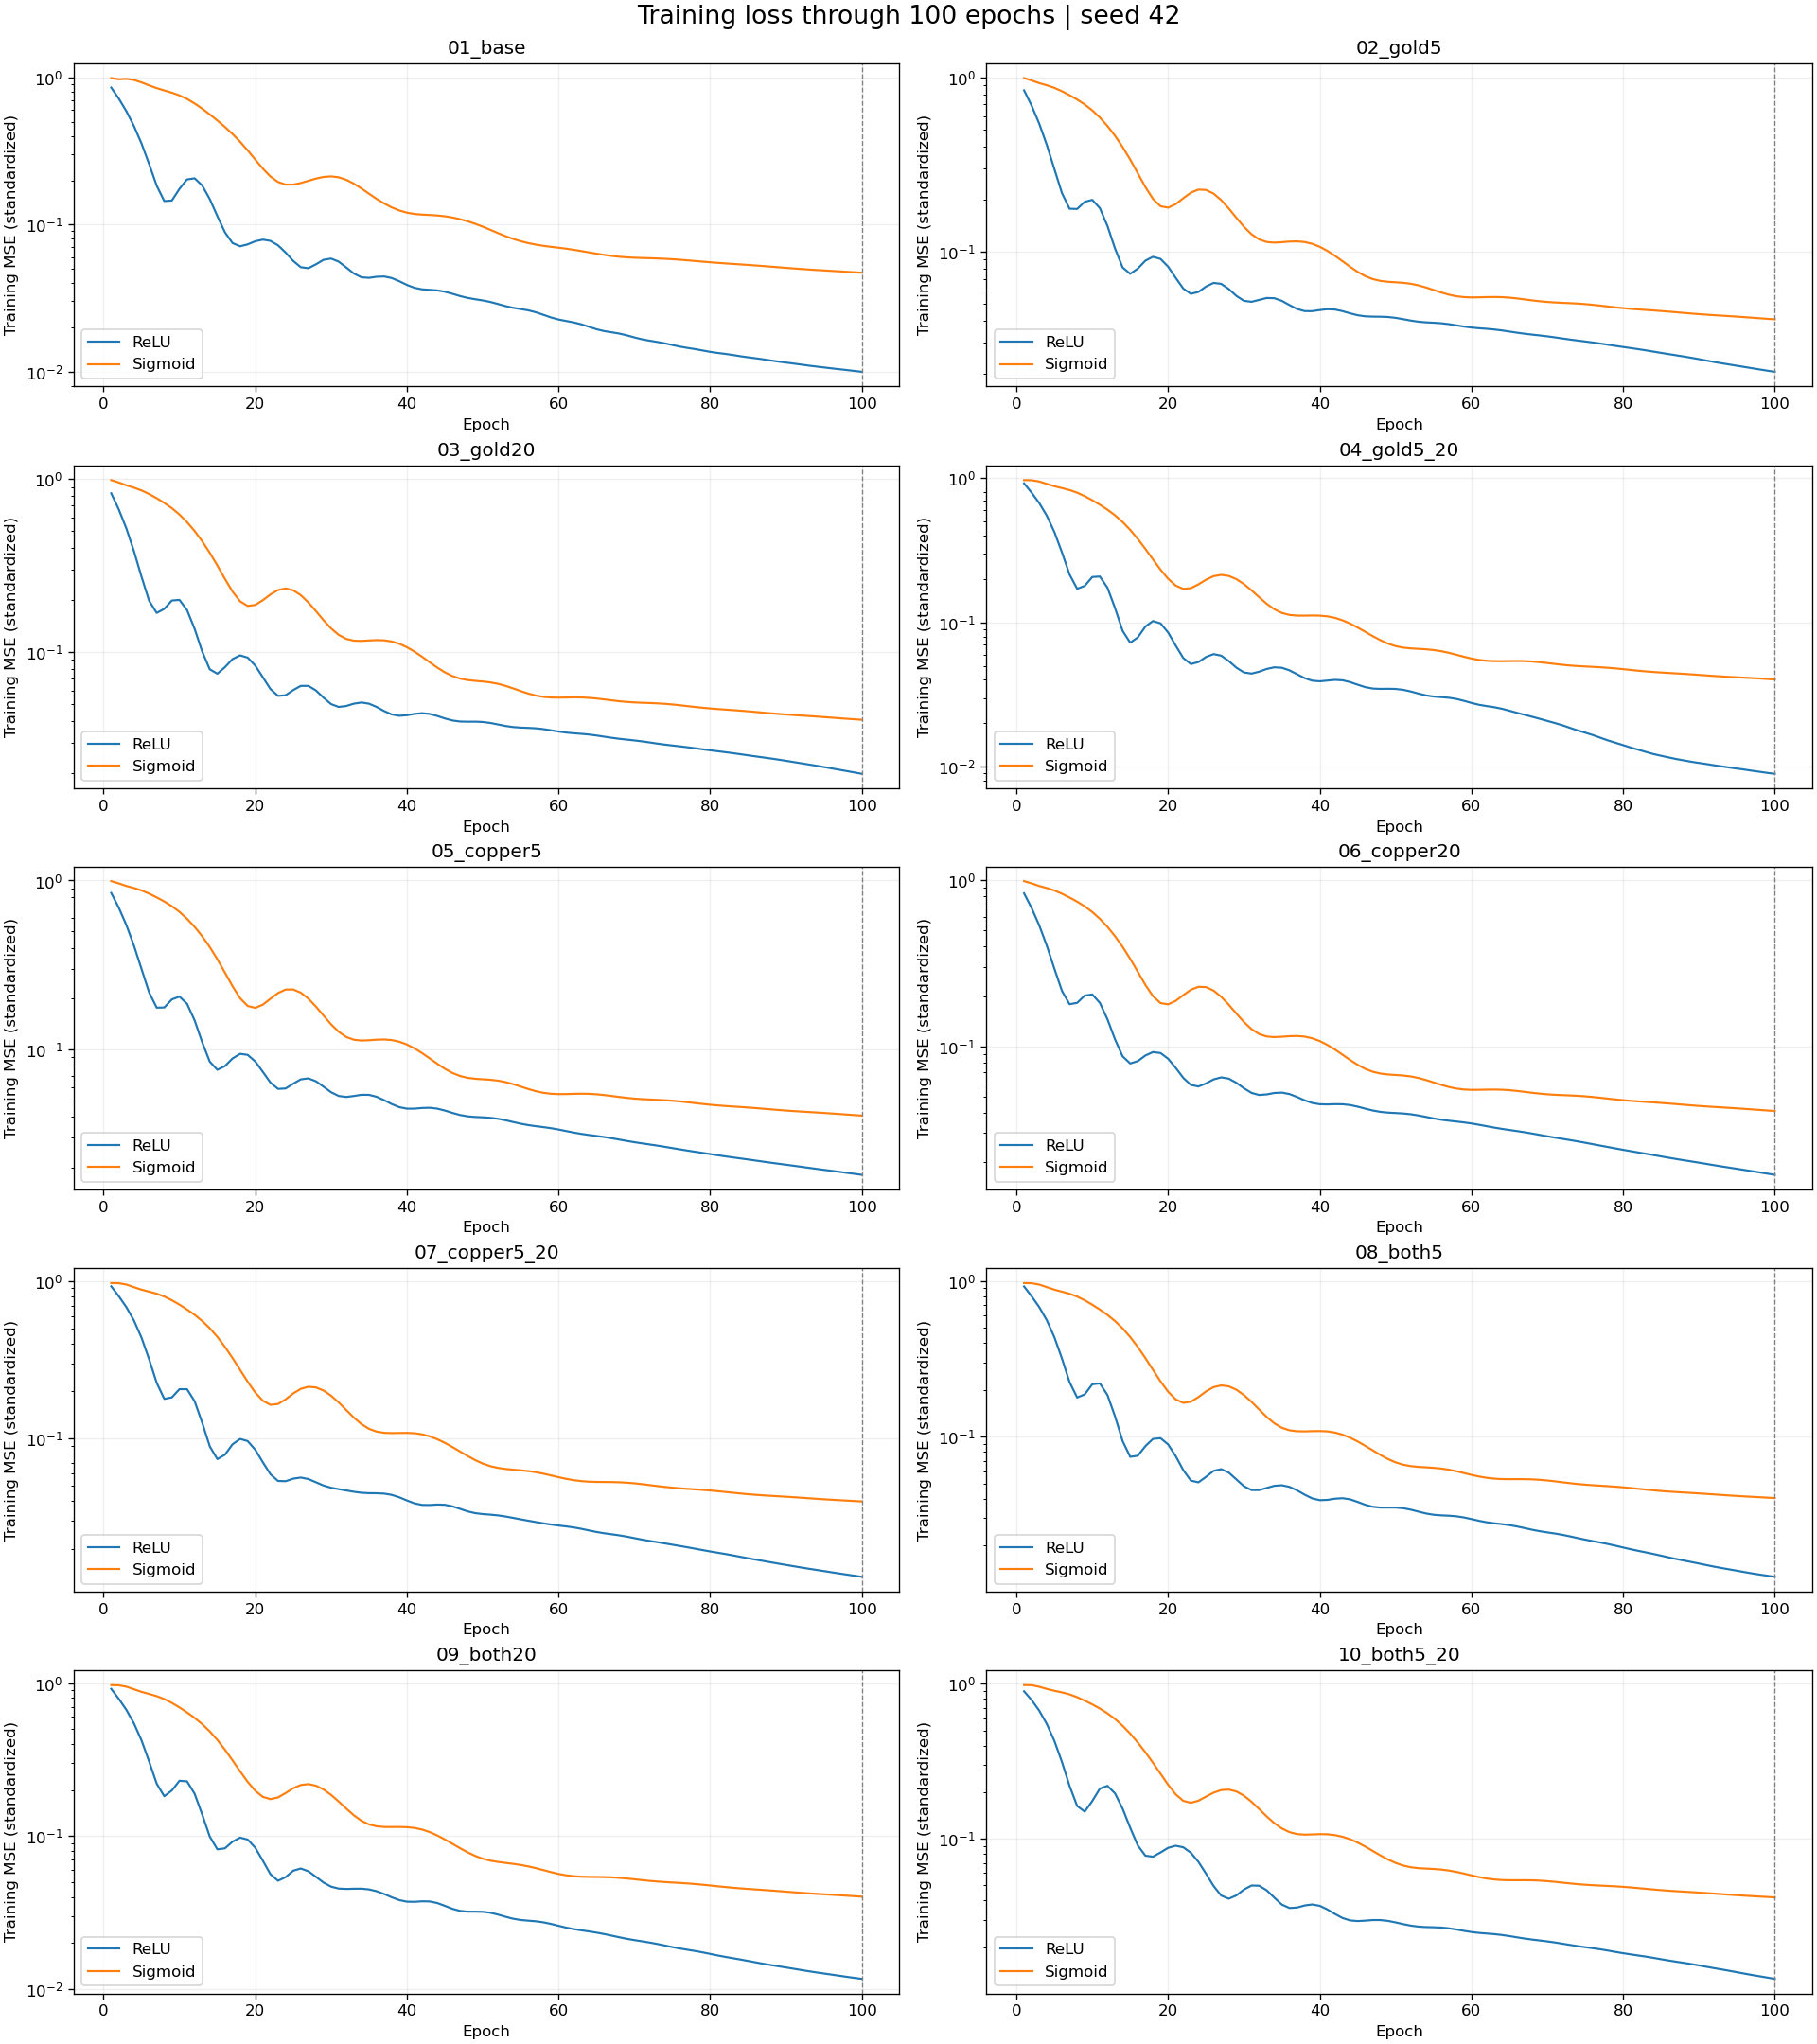

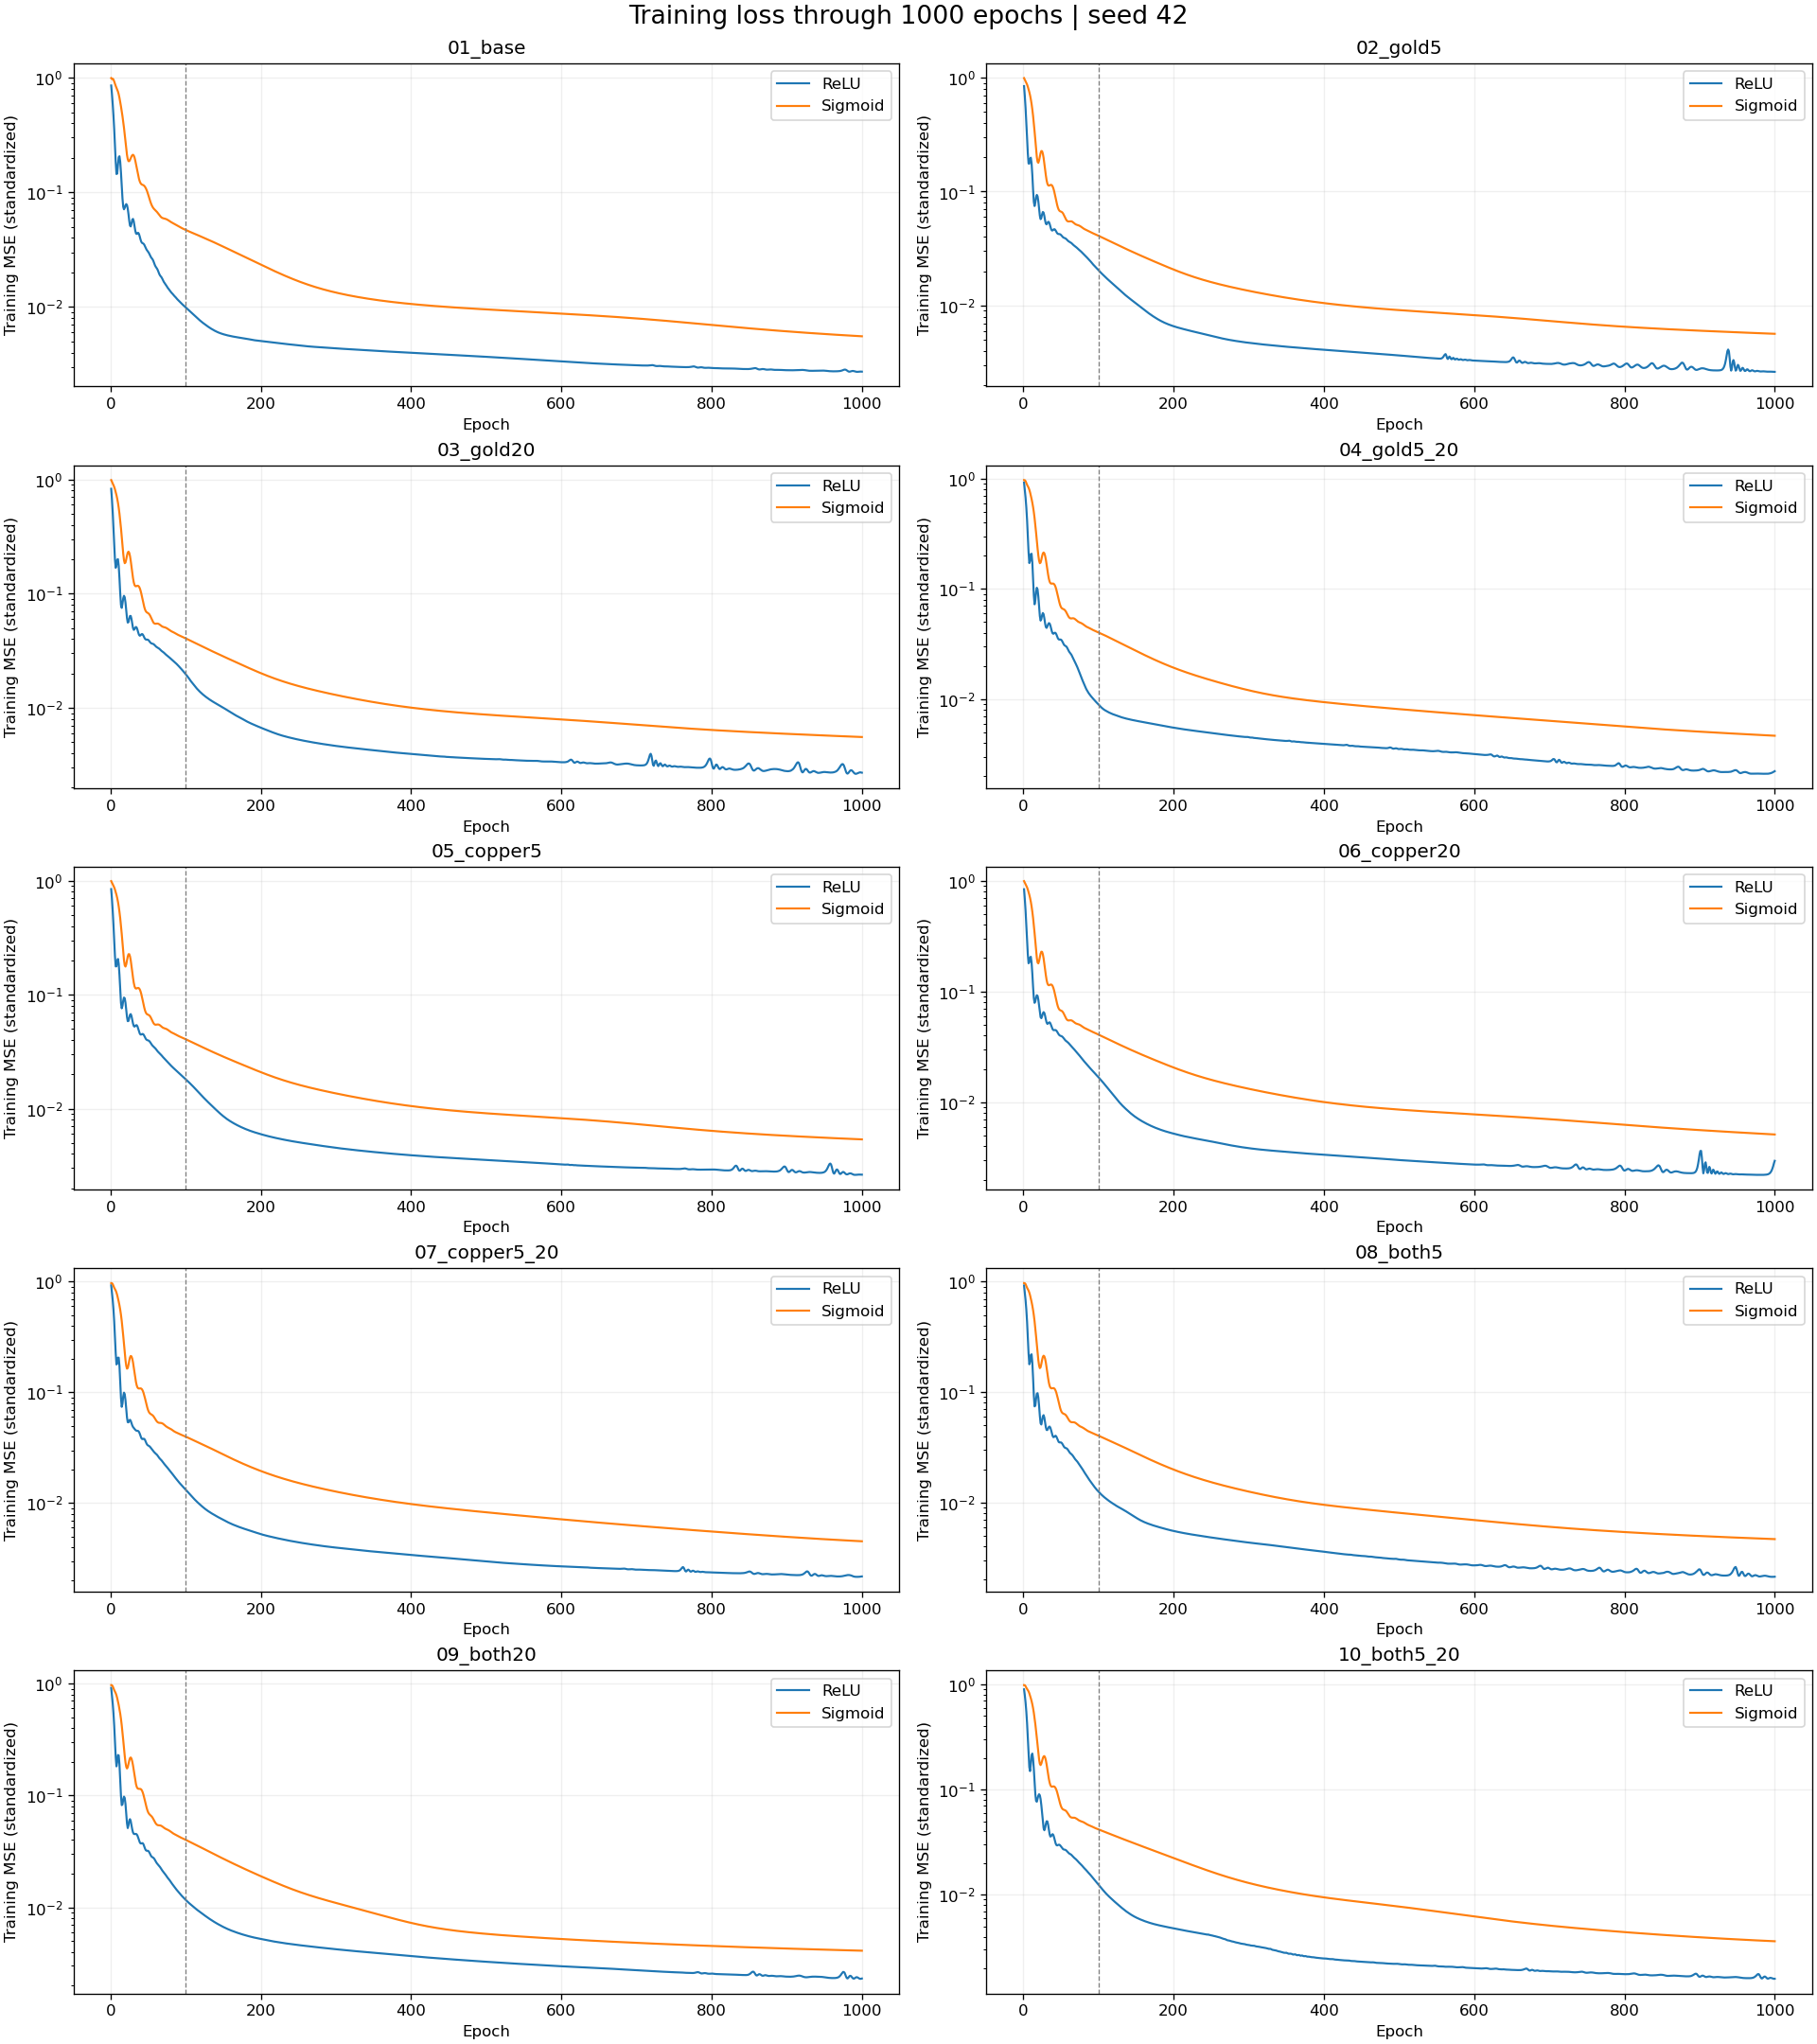

In [3]:
for limit,filename in [(100,'mse_first100.png'),(1000,'mse_extended1000.png')]:
    fig,axes=plt.subplots(5,2,figsize=(16,18),constrained_layout=True)
    for ax,name in zip(axes.flat,EXTRAS):
        for activation in ['ReLU','Sigmoid']:
            h=history[(history.Model==name)&(history.Activation==activation)&(history.Epoch<=limit)]
            ax.plot(h.Epoch,h.MSE_standardized,label=activation,lw=1.3)
        ax.axvline(100,color='gray',ls='--',lw=.8)
        ax.set(title=name,xlabel='Epoch',ylabel='Training MSE (standardized)',yscale='log')
        ax.grid(alpha=.2);ax.legend()
    fig.suptitle(f'Training loss through {limit} epochs | seed 42',fontsize=16)
    fig.savefig(OUT/filename,dpi=120);plt.show()
display(diagnostics.round(5))
count=int((~diagnostics.Plateau_under_1pct_rule).sum())
print(f'{count}/20个模型在101—1000轮至少还有1%的训练MSE下降空间。')
print('1%只是明确的诊断阈值，不是收敛证明；低于阈值也不证明达到最优。')

## 3. 100轮模型的MAPE比较
先分别查看每种激活函数的涨幅组合，再配对比较ReLU与sigmoid。MAPE越小越好；MPE仅补充高估/低估方向。训练MAPE是样本内表现，不能替代测试表现。测试结果属于已查看年份的探索性比较，不据此证明某个组合长期最优。

Activation       ReLU           Sigmoid         
Split           Train     Test    Train     Test
Model                                           
01_base        5.5234  11.4583   9.2163  24.3643
02_gold5       6.4258  10.6552   9.9301  21.0219
03_gold20      6.7107  10.3285   9.9702  20.9870
04_gold5_20    6.1178   7.8041  10.1443  21.5055
05_copper5     6.6162  10.4640   9.8677  20.6683
06_copper20    6.5804  10.5729   9.9270  20.7351
07_copper5_20  6.5917  11.5267  10.0173  20.1711
08_both5       6.2018   6.7151  10.0751  20.7465
09_both20      6.5913   6.5133  10.2181  21.3744
10_both5_20    5.9438   6.0224   9.9098  20.8756

Activation,ReLU,Sigmoid,Sigmoid_minus_ReLU_pp
Model,,,
01_base,11.4583,24.3643,12.9059
02_gold5,10.6552,21.0219,10.3667
03_gold20,10.3285,20.9870,10.6585
04_gold5_20,7.8041,21.5055,13.7014
05_copper5,10.4640,20.6683,10.2043
06_copper20,10.5729,20.7351,10.1622
07_copper5_20,11.5267,20.1711,8.6445
08_both5,6.7151,20.7465,14.0314
09_both20,6.5133,21.3744,14.8610


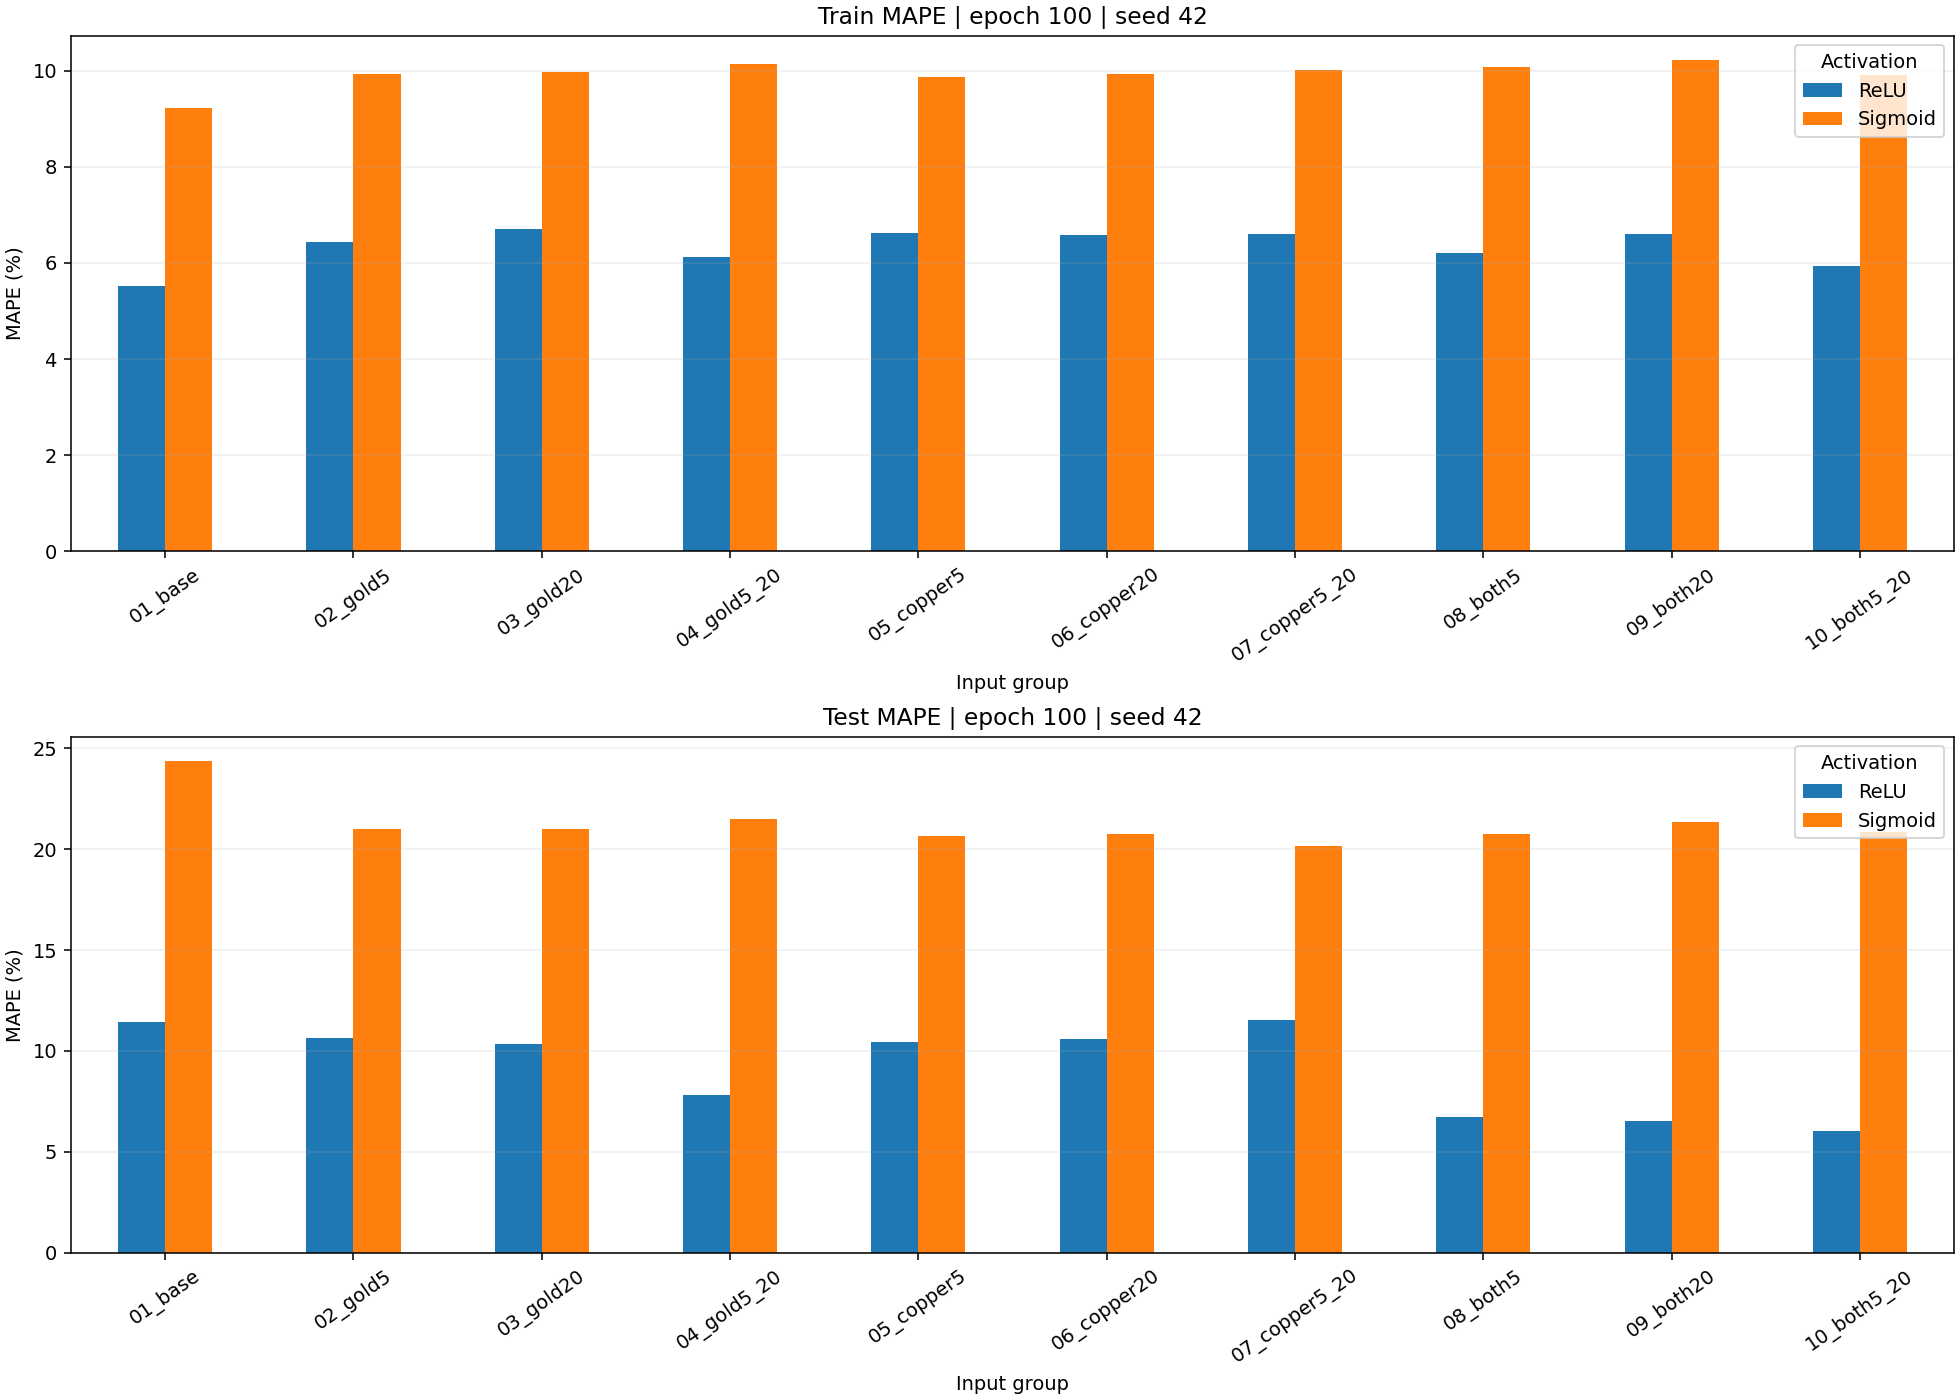

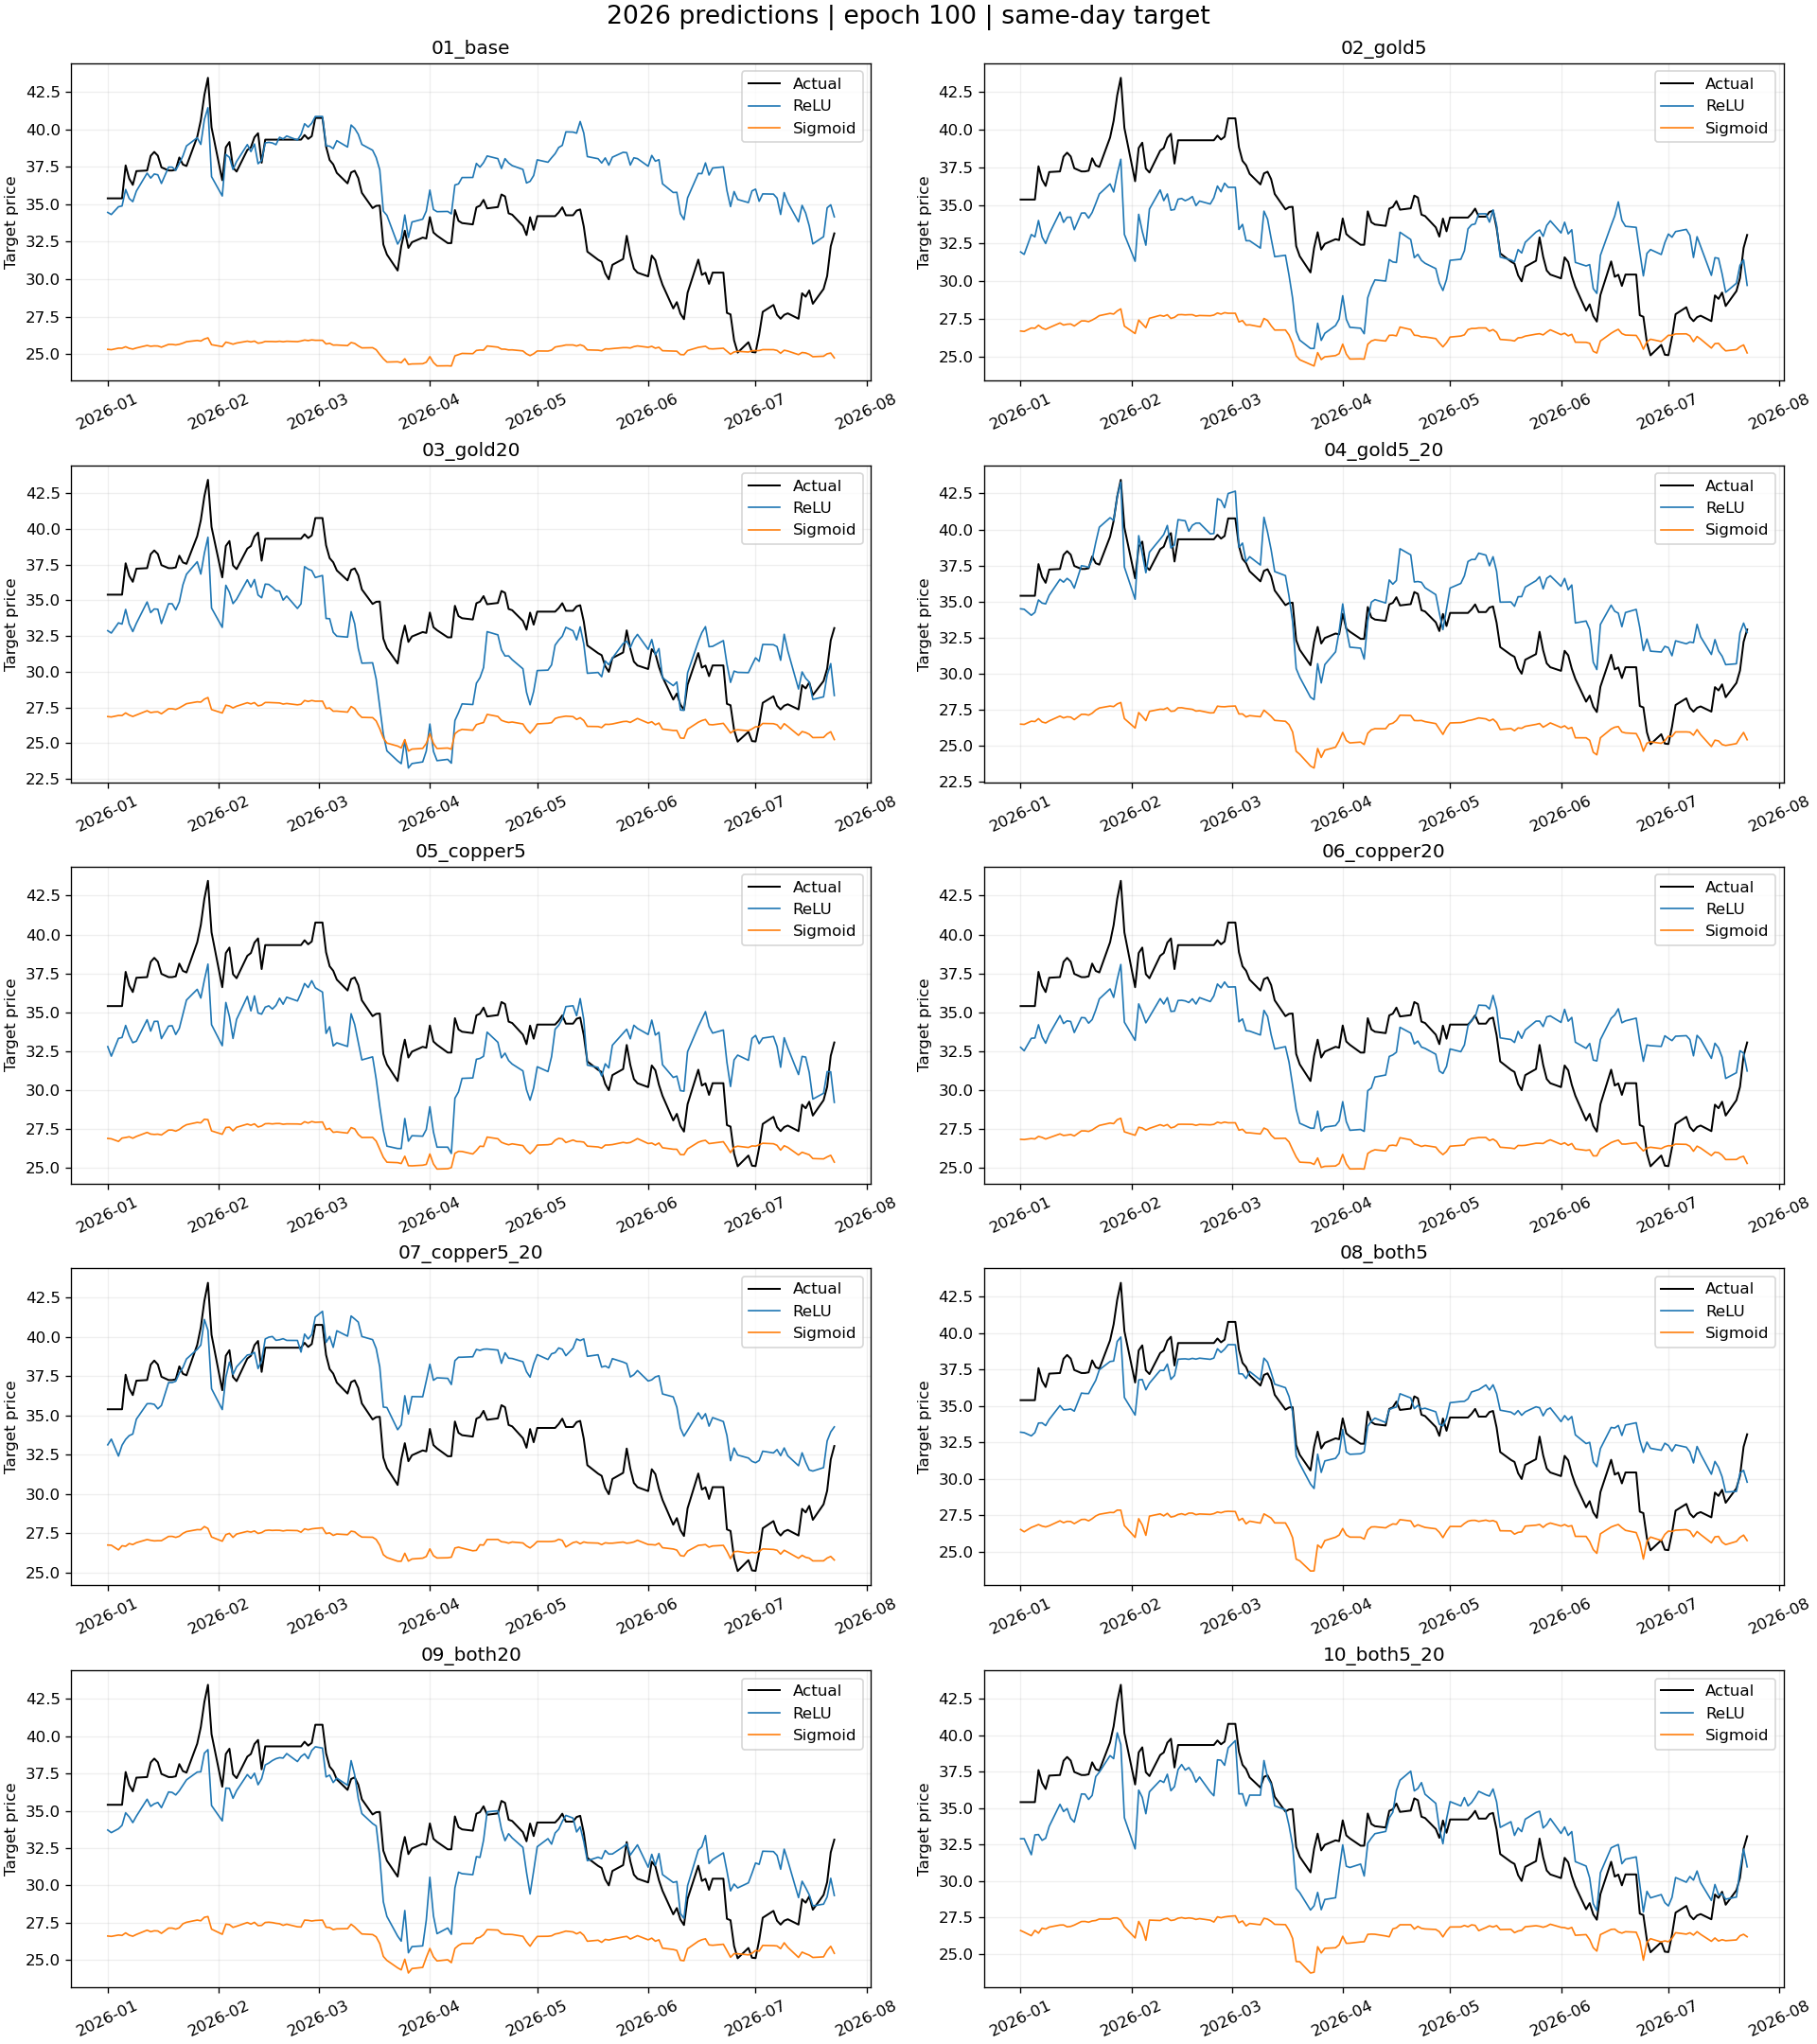

In [4]:
table=metrics.pivot(index='Model',columns=['Activation','Split'],values='MAPE').reindex(EXTRAS)
display(table.round(4));table.to_csv(OUT/'mape_comparison.csv')
test=metrics[metrics.Split=='Test'].pivot(index='Model',columns='Activation',values='MAPE').reindex(EXTRAS)
paired=test.copy();paired['Sigmoid_minus_ReLU_pp']=paired.Sigmoid-paired.ReLU
display(paired.round(4));paired.to_csv(OUT/'activation_paired_mape.csv')
fig,axes=plt.subplots(2,1,figsize=(14,10),constrained_layout=True)
for ax,split in zip(axes,['Train','Test']):
    t=metrics[metrics.Split==split].pivot(index='Model',columns='Activation',values='MAPE').reindex(EXTRAS)
    t.plot.bar(ax=ax,rot=35,color=['tab:blue','tab:orange'])
    ax.set(title=f'{split} MAPE | epoch 100 | seed 42',ylabel='MAPE (%)',xlabel='Input group')
    ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'mape_comparison.png',dpi=140);plt.show()
# 每个输入组画同一测试期真实值及两种激活函数的预测，不挑最好看的组。
fig,axes=plt.subplots(5,2,figsize=(16,18),constrained_layout=True)
for ax,name in zip(axes.flat,EXTRAS):
    ax.plot(te,y.loc[te],label='Actual',color='black',lw=1.2)
    for activation in ['ReLU','Sigmoid']:
        z=predictions[(predictions.Model==name)&(predictions.Activation==activation)&(predictions.Split=='Test')]
        ax.plot(z.Date,z.Predicted,label=activation,lw=1)
    ax.set(title=name,ylabel='Target price');ax.tick_params(axis='x',rotation=25);ax.legend();ax.grid(alpha=.2)
fig.suptitle('2026 predictions | epoch 100 | same-day target',fontsize=16)
fig.savefig(OUT/'test_predictions.png',dpi=120);plt.show()

## 4. 自动生成本次结果摘要
摘要按100轮结果报告，不把延长训练的损失改善当成样本外性能改善。

In [5]:
best=metrics[metrics.Split=='Test'].sort_values('MAPE').iloc[0]
print(f"本次100轮测试MAPE最低：{best.Activation} / {best.Model}，{best.MAPE:.4f}%。")
for activation in ['ReLU','Sigmoid']:
    s=metrics[(metrics.Split=='Test')&(metrics.Activation==activation)].set_index('Model')
    b=s.loc['01_base','MAPE'];row=s.sort_values('MAPE').iloc[0]
    print(f"{activation}: 基准MAPE {b:.4f}%，最低组 {row.name}: {row.MAPE:.4f}%。")
if (~diagnostics.Plateau_under_1pct_rule).any():
    print('不能认定100轮对全部模型已足够：延长训练后仍有模型显著降低训练MSE。当前排名同时受特征、激活函数和训练进度影响。')
else:
    print('按当前延长训练检查，全部模型100轮后进一步下降小于1%；这仍不是全局收敛证明。')
print('若要比较充分训练后的效果，下一步应在2026年以前设置向前验证段选轮数，再重训；不根据2026年MAPE选轮数。')

本次100轮测试MAPE最低：ReLU / 10_both5_20，6.0224%。
ReLU: 基准MAPE 11.4583%，最低组 10_both5_20: 6.0224%。
Sigmoid: 基准MAPE 24.3643%，最低组 07_copper5_20: 20.1711%。
不能认定100轮对全部模型已足够：延长训练后仍有模型显著降低训练MSE。当前排名同时受特征、激活函数和训练进度影响。
若要比较充分训练后的效果，下一步应在2026年以前设置向前验证段选轮数，再重训；不根据2026年MAPE选轮数。


## 本次运行结论

**100轮不足以认定训练已收敛。** 20组模型在101—1000轮内的最低训练MSE，相比第100轮还降低约72.67%—91.35%。全部组均未通过“后续改善小于1%”这一诊断条件。1000轮曲线也不能自动证明已达到最优。

在统一100轮、固定种子42、2026年测试的设置下，ReLU基准MAPE为11.4583%；加入黄金5＋20日为7.8041%；加入金铜5日为6.7151%；加入金铜20日为6.5133%；加入金铜5＋20日为6.0224%，是本轮最低。仅加铜5＋20日为11.5267%，并非增加涨幅就一定改善。

sigmoid基准为24.3643%，其最低组为铜5＋20日（20.1711%）。在这套固定学习率、100轮训练下，sigmoid各对应组均比ReLU差，但训练收敛速度明显不同，不能把差距全部归因于激活函数的表达能力或“平滑是否更合适”。

主MAPE结果严格来自第100轮权重。1000轮仅检查训练收敛，没有根据2026年测试表现选择训练轮次。若要继续比较充分训练后的模型，应另用2026年以前的时间验证段选轮数，而不是凭测试集表现追求更低误差。

---

在特征构造改变后,之前选择的100便没有理由了.从图上来看,训练到1000轮左右才接近收敛.但是从Sigmoid和Relu的对比,我们很显然应该放弃Sigmoid.  
针对我们可能的训练不足的问题,以训练集损失下降少于1%为标准,作为停止训练的轮数.  
在100轮的条件下,我们得到的结果是信息最充分的加入金铜价格5_20日的相对变化.

| 新增特征 | ReLU | sigmoid |
|---|---:|---:|
| 基准 | 11.46% | 24.36% |
| 金5日 | 10.66% | 21.02% |
| 金20日 | 10.33% | 20.99% |
| 金5＋20日 | 7.80% | 21.51% |
| 铜5日 | 10.46% | 20.67% |
| 铜20日 | 10.57% | 20.74% |
| 铜5＋20日 | 11.53% | 20.17% |
| 金铜5日 | 6.72% | 20.75% |
| 金铜20日 | 6.51% | 21.37% |
| 金铜5＋20日 | **6.02%** | 20.88% |

通过比较,我们可以看出,以当前的数据测试,黄金的短期和中期价格而非铜显著影响股价的预测.  
但是,单看铜的效果不大,但是将铜和金结合在一起,效果有明显的改变.因此,我们应该保留金铜短期的价格.

---

## 继续增加训练轮数,在进行对比.看看是否这个结论还成立.我们以训练集最优为训练轮数.

# ReLU：训练MSE停止显著改善后，再比较10种输入组合

本节可独立运行，不需要重跑前面的sigmoid实验。保留原7个水平变量，不加入时间。10种涨幅组合、标准化、2026年测试集、种子42、Adam学习率0.01及隐藏层16/32保持不变。

**停止规则**：将“无法下降1%”定义为相对改善阈值1%，耐心窗口100轮。每当训练MSE比上一次有效改善基准降低至少1%，更新基准并重置等待轮数；连续100轮未达到这个幅度，就停止。不是单轮下降不到1%便停止。最大10000轮作为上限；触及上限单独标记，不能声称满足停止条件。

停止时恢复整个训练过程中MSE最低的权重，报告该最佳轮数与实际停止轮数。最佳权重每次只要损失更小便保存，1%只控制等待计时。使用更新后的训练MSE，测试集不参与选轮或停止。

这个规则代表训练损失趋缓，不保证全局最优，也不保证样本外误差更小。100轮耐心窗口是本次明确选定的操作口径，可能在长平台后继续下降之前停下。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_CONV_OUT',str(ROOT/'results/mlp_relu_convergence_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}
tr=x.index[x.index.year<2026];te=x.index[x.index.year==2026]
assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all()
splits=pd.DataFrame([{'Split':s,'N':len(idx),'Start':idx.min(),'End':idx.max()} for s,idx in [('Train',tr),('Test',te)]])
display(splits);splits.to_csv(OUT/'splits.csv',index=False)
config={'seed':SEED,'lr':LR,'main_epochs':MAIN_EPOCHS,'diagnostic_epochs':DIAG_EPOCHS,'base':BASE,'extras':EXTRAS,
'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
sy=StandardScaler().fit(y.loc[tr].to_numpy().reshape(-1,1))
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
yt=tensor(sy.transform(y.loc[tr].to_numpy().reshape(-1,1)))
REL_MIN_DELTA,PATIENCE,MAX_EPOCHS=.01,100,10000
config.update(relative_min_delta=REL_MIN_DELTA,patience=PATIENCE,max_epochs=MAX_EPOCHS,activation='ReLU',selection='minimum training MSE')
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))


Out[1]: 1009


,Split,N,Start,End
0,Train,3665,2012-06-06,2025-12-31
1,Test,152,2026-01-01,2026-07-23


In [2]:
rows,curves,pred_frames,selection_rows=[],[],[],[]
for name,extra in EXTRAS.items():
    cols=BASE+extra
    sx=StandardScaler().fit(x.loc[tr,cols]);xt=tensor(sx.transform(x.loc[tr,cols]))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(cols),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    best_loss,reference=float('inf'),float('inf')
    best_epoch,waiting=0,0;history=[]
    for epoch in range(1,MAX_EPOCHS+1):
        model.train();opt.zero_grad()
        loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():current=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(current)
        if current<best_loss:
            best_loss,best_epoch,best_state=current,epoch,deepcopy(model.state_dict())
        significant=current<=reference*(1-REL_MIN_DELTA)
        if significant:reference,waiting=current,0
        else:waiting+=1
        history.append({'Model':name,'Epoch':epoch,'MSE_standardized':current,
            'MSE_original':current*sy.scale_[0]**2,'Best_MSE':best_loss,
            'Reference_MSE':reference,'Waiting':waiting,'Significant_improvement':significant})
        if epoch==100:state100=deepcopy(model.state_dict())
        if waiting>=PATIENCE:break
    stop_reason='plateau_1pct_100epochs' if waiting>=PATIENCE else 'max_epochs'
    model.load_state_dict(best_state);model.eval()
    with torch.no_grad():verified=((model(xt)-yt)**2).mean().item()
    assert np.isclose(verified,best_loss,rtol=1e-6)
    h=pd.DataFrame(history);curves.append(h)
    selection_rows.append({'Model':name,'Inputs':len(cols),'Best_epoch':best_epoch,'Stop_epoch':epoch,
        'Stop_reason':stop_reason,'Best_train_MSE':best_loss,'Epoch100_train_MSE':h.loc[h.Epoch==100,'MSE_standardized'].iloc[0],
        'Improvement_vs_100_percent':100*(1-best_loss/h.loc[h.Epoch==100,'MSE_standardized'].iloc[0])})
    # 两个阶段使用同一次训练路径的权重，确保100轮对照精确一致。
    for stage,state in [('Epoch100',state100),('Train_best',best_state)]:
        model.load_state_dict(state)
        for split,idx in [('Train',tr),('Test',te)]:
            with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,cols]))).numpy()).ravel()
            truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            assert np.isfinite(pred).all()
            rows.append({'Model':name,'Stage':stage,'Split':split,'MAPE':np.abs(pe).mean(),'MPE':pe.mean(),'N':len(idx)})
            pred_frames.append(pd.DataFrame({'Date':idx,'Model':name,'Stage':stage,'Split':split,
                'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
    torch.save({'state_dict':best_state,'features':cols,'activation':'ReLU','seed':SEED,
        'best_epoch':best_epoch,'stop_epoch':epoch,'stop_reason':stop_reason,'best_train_mse':best_loss,
        'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist(),
        'relative_min_delta':REL_MIN_DELTA,'patience':PATIENCE},OUT/f'{name}_train_best.pt')
    print(f'{name}: 最佳{best_epoch}轮 / 停止{epoch}轮 / {stop_reason}',flush=True)
selection=pd.DataFrame(selection_rows);history=pd.concat(curves,ignore_index=True)
metrics=pd.DataFrame(rows);predictions=pd.concat(pred_frames,ignore_index=True)
for key,frame in [('selection',selection),('training_history',history),('metrics',metrics),('predictions',predictions)]:
    frame.to_csv(OUT/f'{key}.csv',index=False)
display(selection.round(5))

01_base: 最佳2441轮 / 停止2475轮 / plateau_1pct_100epochs
02_gold5: 最佳2183轮 / 停止2187轮 / plateau_1pct_100epochs
03_gold20: 最佳2007轮 / 停止2007轮 / plateau_1pct_100epochs
04_gold5_20: 最佳2793轮 / 停止2804轮 / plateau_1pct_100epochs
05_copper5: 最佳2872轮 / 停止2895轮 / plateau_1pct_100epochs
06_copper20: 最佳2214轮 / 停止2259轮 / plateau_1pct_100epochs
07_copper5_20: 最佳3249轮 / 停止3265轮 / plateau_1pct_100epochs
08_both5: 最佳2210轮 / 停止2229轮 / plateau_1pct_100epochs
09_both20: 最佳2505轮 / 停止2535轮 / plateau_1pct_100epochs
10_both5_20: 最佳2019轮 / 停止2044轮 / plateau_1pct_100epochs


,Model,Inputs,Best_epoch,Stop_epoch,Stop_reason,Best_train_MSE,Epoch100_train_MSE,Improvement_vs_100_percent
0,01_base,7,2441,2475,plateau_1pct_100epochs,0.00194,0.00994,80.47553
1,02_gold5,8,2183,2187,plateau_1pct_100epochs,0.00210,0.02047,89.72857
2,03_gold20,8,2007,2007,plateau_1pct_100epochs,0.00220,0.01975,88.84305
3,04_gold5_20,9,2793,2804,plateau_1pct_100epochs,0.00136,0.00893,84.77741
4,05_copper5,8,2872,2895,plateau_1pct_100epochs,0.00186,0.01813,89.76446
5,06_copper20,8,2214,2259,plateau_1pct_100epochs,0.00176,0.01683,89.52361
6,07_copper5_20,9,3249,3265,plateau_1pct_100epochs,0.00142,0.01325,89.28110
7,08_both5,9,2210,2229,plateau_1pct_100epochs,0.00156,0.01258,87.58275
8,09_both20,9,2505,2535,plateau_1pct_100epochs,0.00166,0.01166,85.78399
9,10_both5_20,11,2019,2044,plateau_1pct_100epochs,0.00127,0.01247,89.84221


## 训练MSE与实际停止位置
每组分别标出100轮、训练MSE最低轮和停止轮；图上显示的是训练损失，不是测试误差。

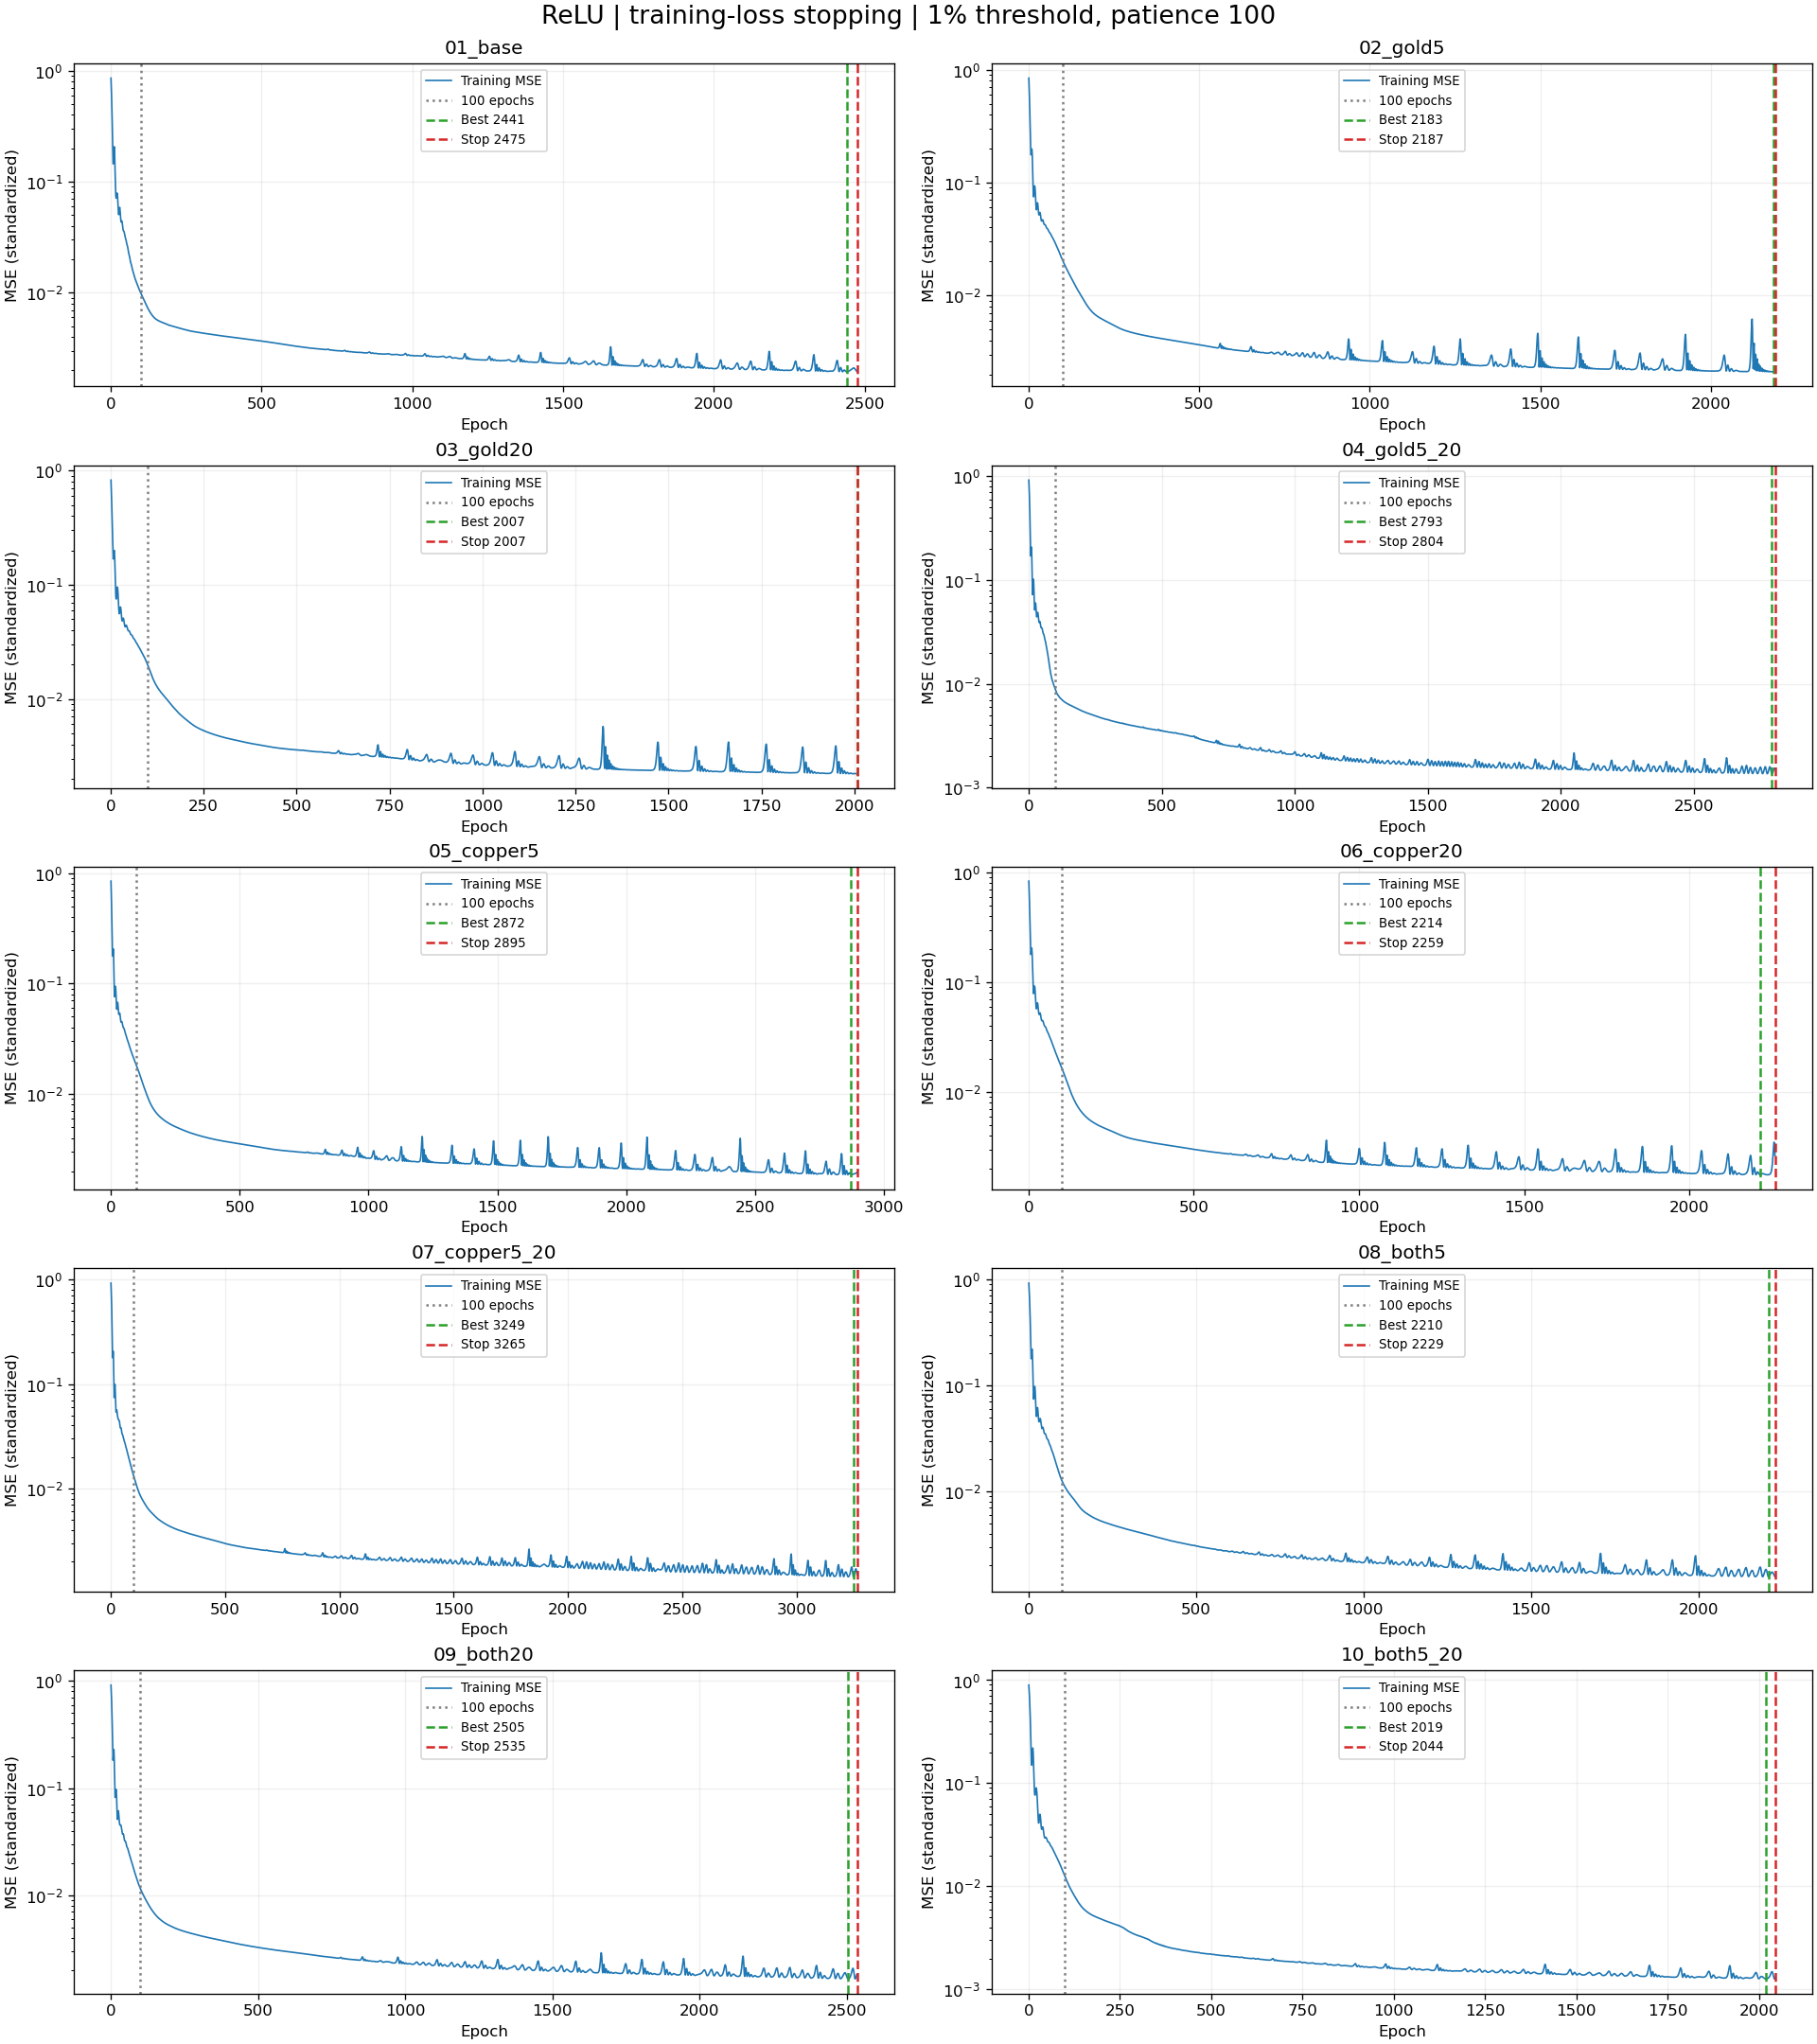

In [3]:
fig,axes=plt.subplots(5,2,figsize=(16,18),constrained_layout=True)
for ax,name in zip(axes.flat,EXTRAS):
    h=history[history.Model==name];s=selection.set_index('Model').loc[name]
    ax.plot(h.Epoch,h.MSE_standardized,color='tab:blue',lw=1,label='Training MSE')
    ax.axvline(100,color='gray',ls=':',label='100 epochs')
    ax.axvline(s.Best_epoch,color='tab:green',ls='--',label=f'Best {s.Best_epoch}')
    ax.axvline(s.Stop_epoch,color='tab:red',ls='--',label=f'Stop {s.Stop_epoch}')
    ax.set(title=name,yscale='log',xlabel='Epoch',ylabel='MSE (standardized)');ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.suptitle('ReLU | training-loss stopping | 1% threshold, patience 100',fontsize=16)
fig.savefig(OUT/'training_convergence.png',dpi=120);plt.show()

## 2026年MAPE：100轮 vs 训练最优权重
按同一训练路径比较两个阶段，不因不同训练次数更换随机初始化。输入越多不保证预测信息越多；新增变量可能冗余，并同时改变参数量。本次结果只能回答固定种子、这段测试数据下哪组误差最低。

训练最优权重的2026年MAPE排名：
最低MAPE：01_base = 5.2873%
金铜5+20日全组合：9.4410%，排名6/10。
全组合本次不再最好。
训练MSE最优不是测试MAPE最优；不根据这里的2026年结果回头选择训练轮数。


Stage         Epoch100          Train_best         
Split            Train     Test      Train     Test
Model                                              
01_base         5.5234  11.4583     2.4834   5.2873
02_gold5        6.4258  10.6552     2.7600  21.2162
03_gold20       6.7107  10.3285     2.8685  15.2415
04_gold5_20     6.1178   7.8041     2.3194   7.3520
05_copper5      6.6162  10.4640     2.6812   9.0358
06_copper20     6.5804  10.5729     2.4806  10.0524
07_copper5_20   6.5917  11.5267     2.3800  14.1001
08_both5        6.2018   6.7151     2.5465   8.7408
09_both20       6.5913   6.5133     2.5002   7.1236
10_both5_20     5.9438   6.0224     2.2760   9.4410

Stage,Epoch100,Train_best,Change_pp
Model,,,
01_base,11.4583,5.2873,-6.1710
02_gold5,10.6552,21.2162,10.5609
03_gold20,10.3285,15.2415,4.9130
04_gold5_20,7.8041,7.3520,-0.4521
05_copper5,10.4640,9.0358,-1.4282
06_copper20,10.5729,10.0524,-0.5204
07_copper5_20,11.5267,14.1001,2.5734
08_both5,6.7151,8.7408,2.0257
09_both20,6.5133,7.1236,0.6103


Stage,Epoch100,Train_best,Change_pp
Model,,,
01_base,11.4583,5.2873,-6.1710
09_both20,6.5133,7.1236,0.6103
04_gold5_20,7.8041,7.3520,-0.4521
08_both5,6.7151,8.7408,2.0257
05_copper5,10.4640,9.0358,-1.4282
10_both5_20,6.0224,9.4410,3.4186
06_copper20,10.5729,10.0524,-0.5204
07_copper5_20,11.5267,14.1001,2.5734
03_gold20,10.3285,15.2415,4.9130


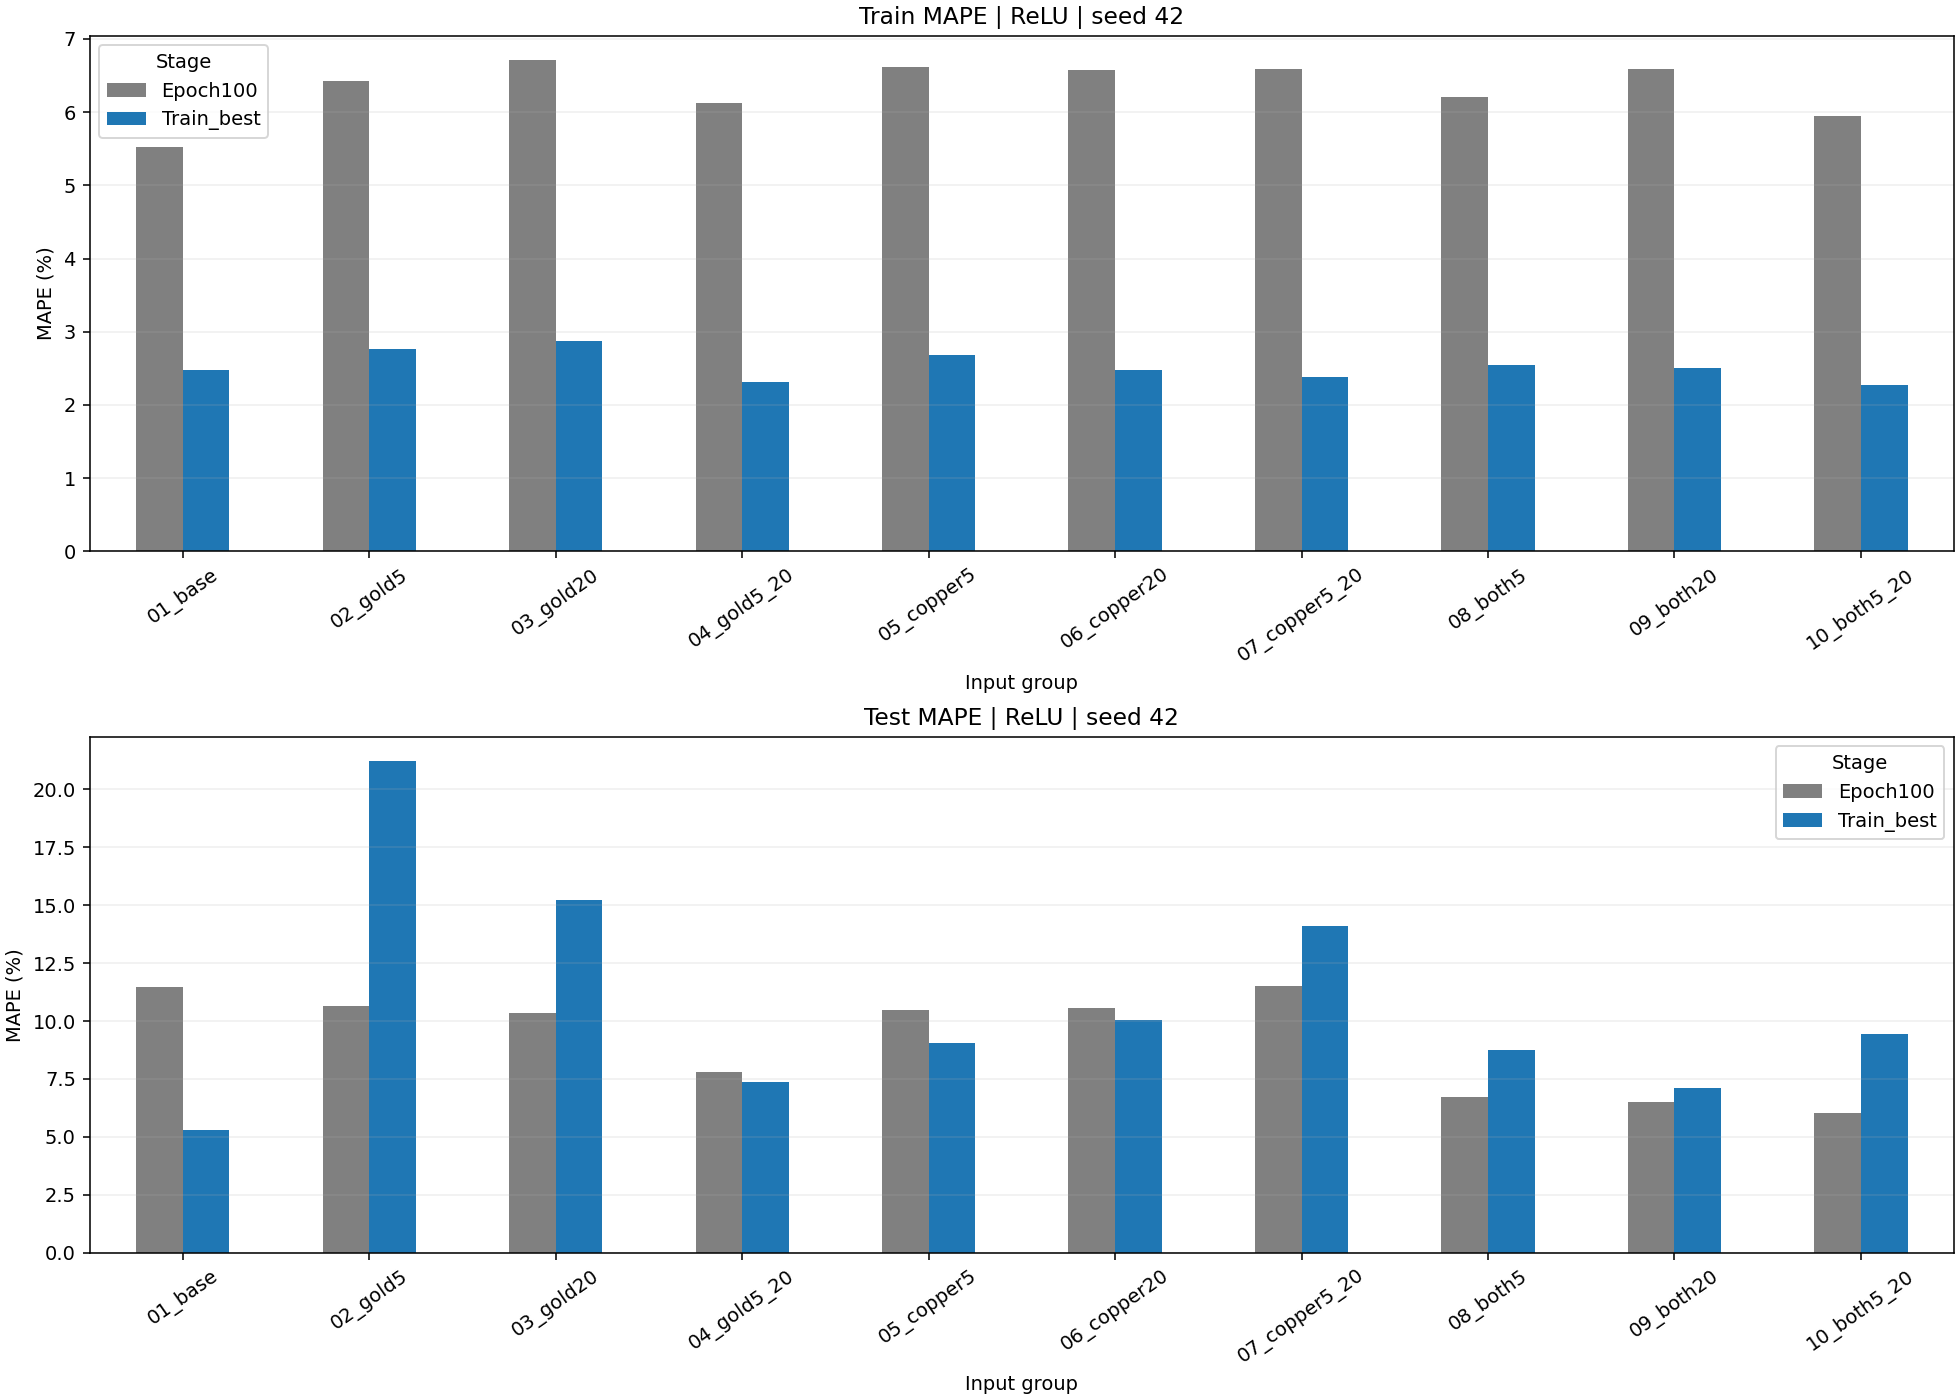

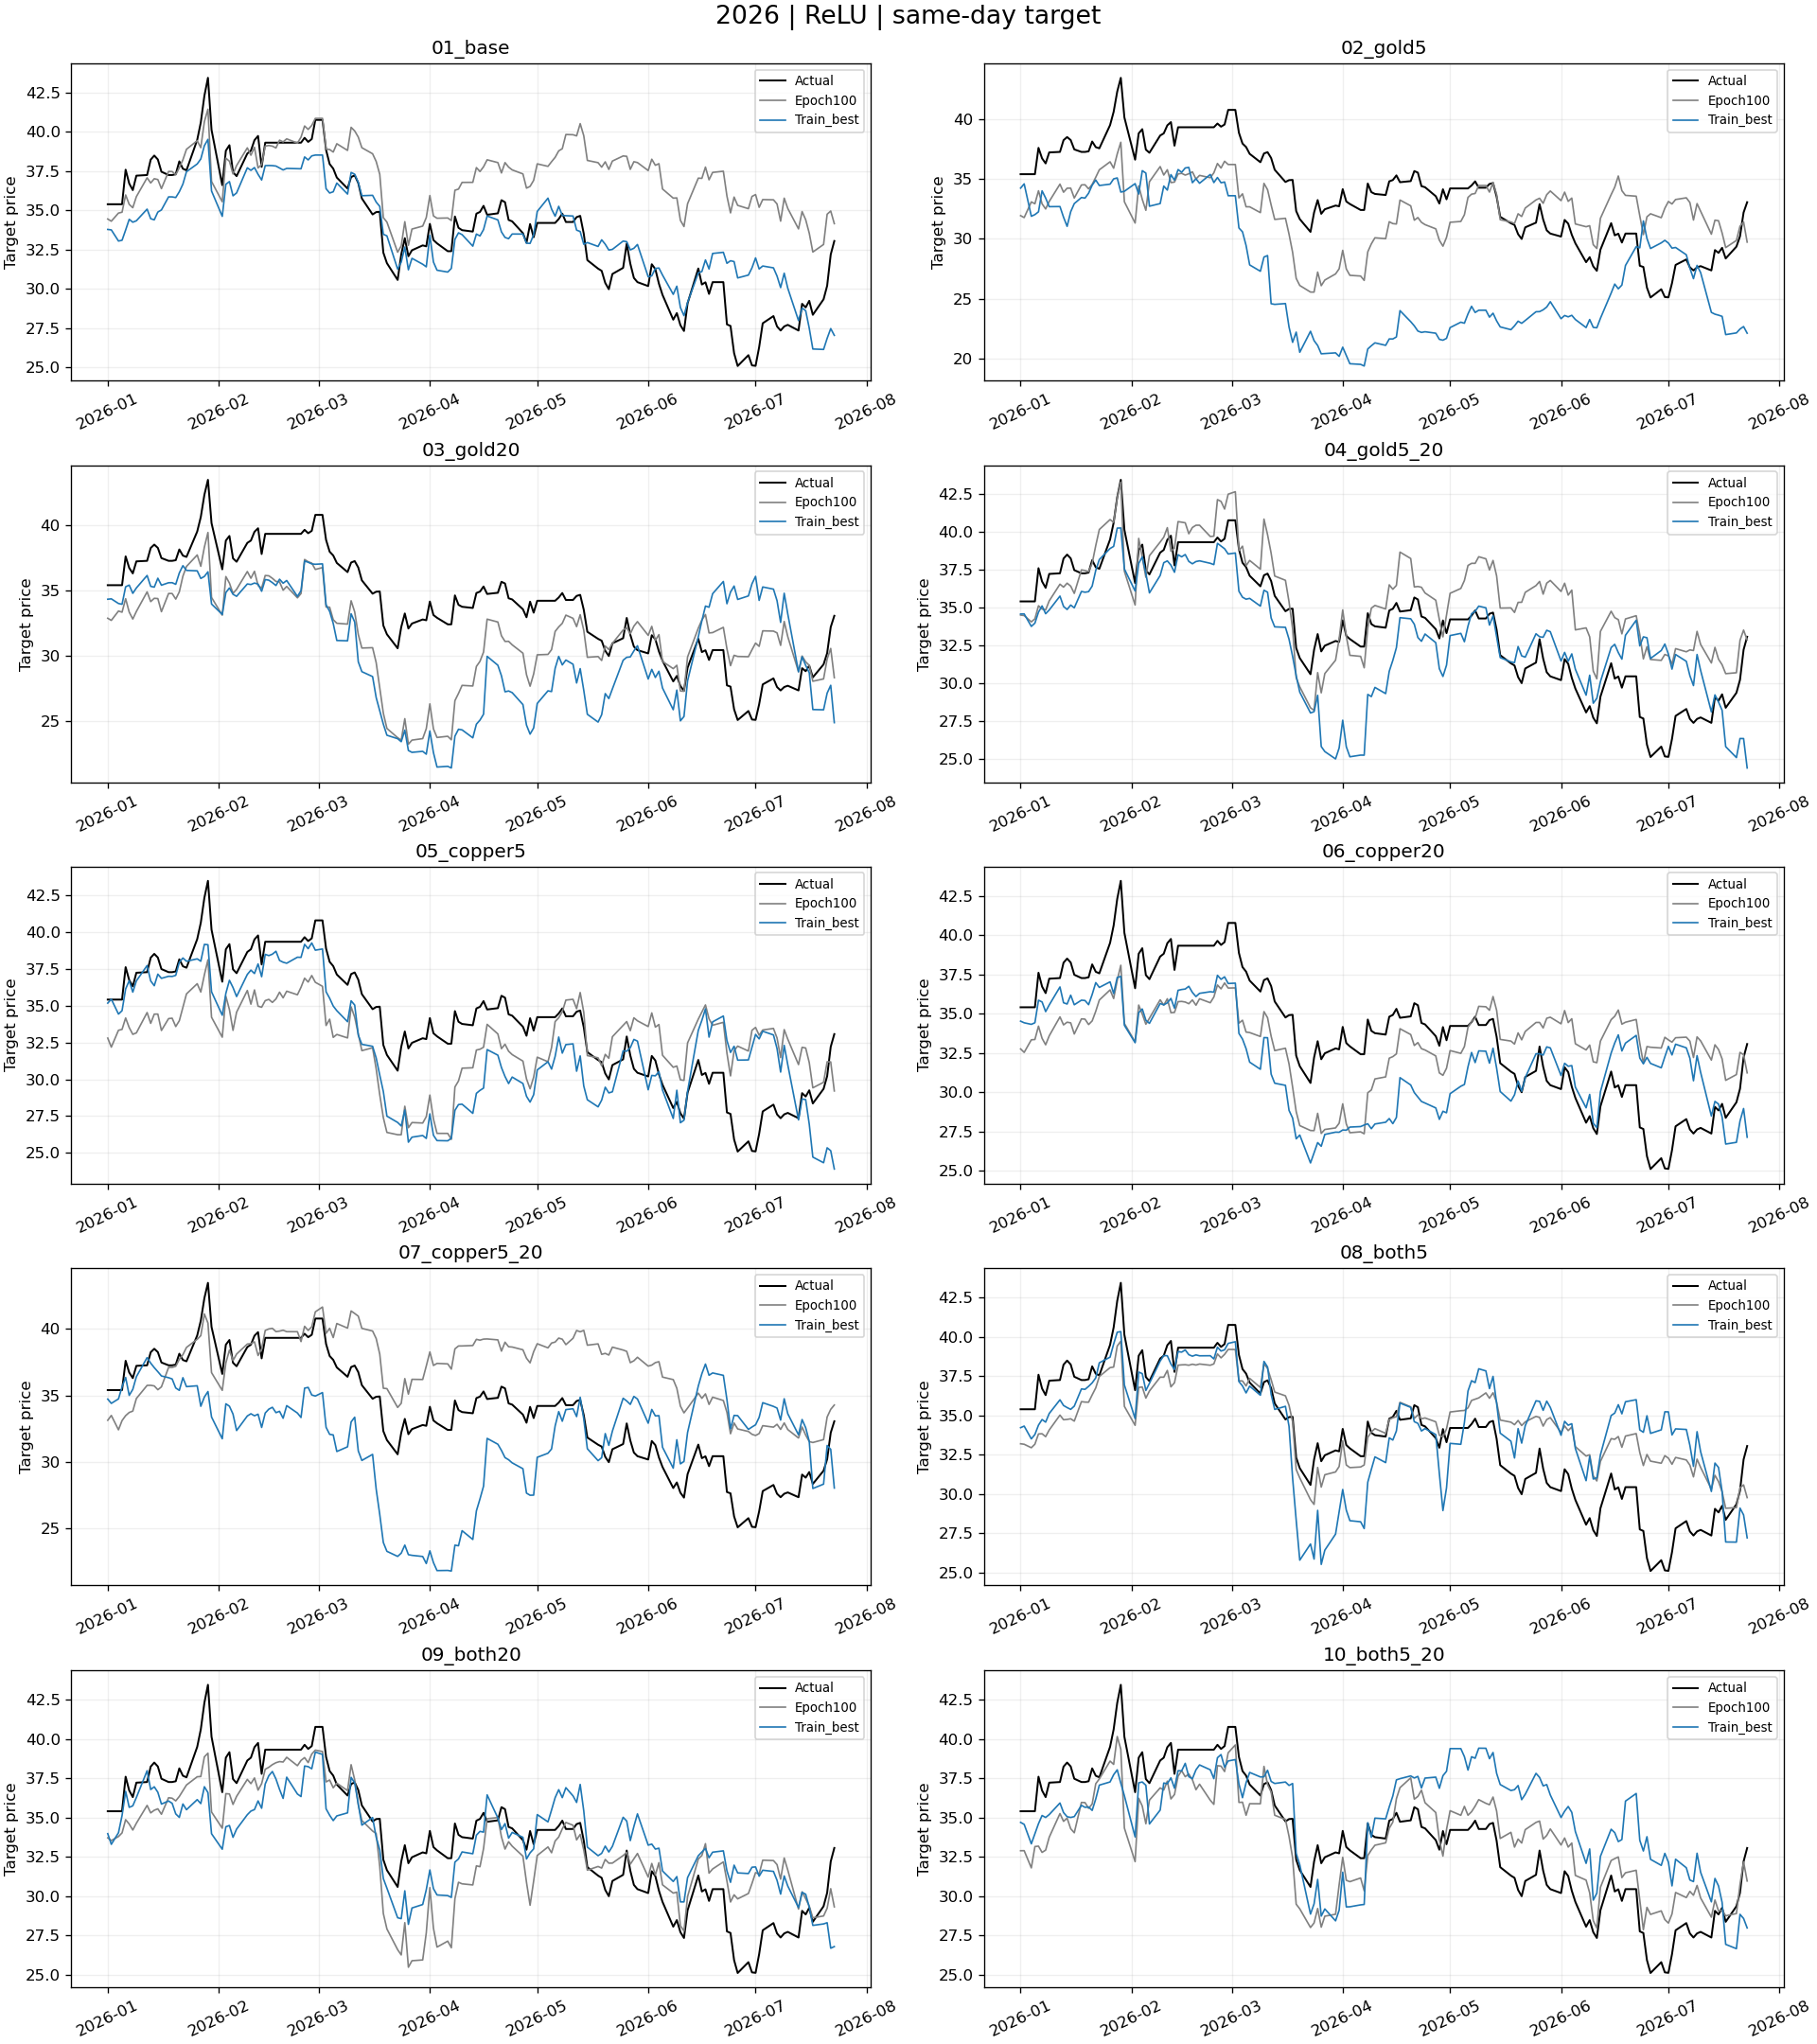

In [4]:
table=metrics.pivot(index='Model',columns=['Stage','Split'],values='MAPE').reindex(EXTRAS)
display(table.round(4));table.to_csv(OUT/'mape_comparison.csv')
test=metrics[metrics.Split=='Test'].pivot(index='Model',columns='Stage',values='MAPE').reindex(EXTRAS)
test['Change_pp']=test.Train_best-test.Epoch100
display(test.round(4));test.to_csv(OUT/'test_comparison.csv')
fig,axes=plt.subplots(2,1,figsize=(14,10),constrained_layout=True)
for ax,split in zip(axes,['Train','Test']):
    t=metrics[metrics.Split==split].pivot(index='Model',columns='Stage',values='MAPE').reindex(EXTRAS)
    t[['Epoch100','Train_best']].plot.bar(ax=ax,rot=35,color=['gray','tab:blue'])
    ax.set(title=f'{split} MAPE | ReLU | seed 42',ylabel='MAPE (%)',xlabel='Input group');ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'mape_comparison.png',dpi=140);plt.show()
fig,axes=plt.subplots(5,2,figsize=(16,18),constrained_layout=True)
for ax,name in zip(axes.flat,EXTRAS):
    ax.plot(te,y.loc[te],color='black',label='Actual',lw=1.2)
    for stage,color in [('Epoch100','gray'),('Train_best','tab:blue')]:
        p=predictions[(predictions.Model==name)&(predictions.Stage==stage)&(predictions.Split=='Test')]
        ax.plot(p.Date,p.Predicted,label=stage,color=color,lw=1)
    ax.set(title=name,ylabel='Target price');ax.tick_params(axis='x',rotation=25);ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.suptitle('2026 | ReLU | same-day target',fontsize=16)
fig.savefig(OUT/'test_predictions.png',dpi=120);plt.show()
ranking=test.sort_values('Train_best')
print('训练最优权重的2026年MAPE排名：');display(ranking.round(4))
full='10_both5_20';best=ranking.index[0]
print(f'最低MAPE：{best} = {ranking.iloc[0].Train_best:.4f}%')
print(f'金铜5+20日全组合：{test.loc[full,"Train_best"]:.4f}%，排名{list(ranking.index).index(full)+1}/10。')
print('全组合本次仍最好。' if best==full else '全组合本次不再最好。')
if (selection.Stop_reason=='max_epochs').any():print('注意：部分模型触及轮数上限，未满足停止规则。')
print('训练MSE最优不是测试MAPE最优；不根据这里的2026年结果回头选择训练轮数。')

## 本轮结论：全组合不再最好

10组ReLU都达到“连续100轮没有相对上次有效改善基准降低至少1%”的训练MSE停止条件，停止轮数2007—3265；未触及10000轮上限。评价恢复各自训练MSE最低权重，最佳轮数与停止轮数分开记录。

本次2026测试MAPE最低的是**原7变量基准：5.2873%**（训练最优权重第2441轮，停止第2475轮）；其次金铜20日7.1236%，黄金5＋20日7.3520%。金铜5＋20日全组合为9.4410%，排名第6，相比100轮的6.0224%反而增加3.4186个百分点。

因此，在本次种子42和停止规则下，不支持“涨幅变量越多，预测越好”。20个100轮训练/测试MAPE与上一节精确复现，阶段差异来自同一训练路径继续训练及训练最优权重选择。

所有组训练拟合改善，但6/10组测试MAPE变差。训练损失趋缓不等于泛化最优；这与过拟合或外推响应变化相容，尚不能仅凭此确定唯一原因。不能据此断言涨幅无价值，也不能推广为所有年份或初始化下基准都更好。本轮不使用测试MAPE挑选停止轮数。

| 新增特征 | 100轮测试MAPE | 本次测试MAPE |
|---|---:|---:|
| 基准 | 11.46% | **5.29%** |
| 金5日 | 10.66% | 21.22% |
| 金20日 | 10.33% | 15.24% |
| 金5＋20日 | 7.80% | 7.35% |
| 铜5日 | 10.46% | 9.04% |
| 铜20日 | 10.57% | 10.05% |
| 铜5＋20日 | 11.53% | 14.10% |
| 金铜5日 | 6.72% | 8.74% |
| 金铜20日 | 6.51% | 7.12% |
| 金铜5＋20日 | **6.02%** | 9.44% |

在充分训练的情况下,反而基准模型的表现是最好的了.可能过度的训练让模型学到了一些噪声,并不符合实际的情况.  
分别训练中我们可以看到,过多的学习会让铜价的影响放大,影响预测的准确率.  
过拟合的模型,是否一直表现不好?我们保留100轮的金铜5_20日与充分训练的基准模型,通过多年的比较来判断两者的作用.

---

# 2015—2026逐年测试：全涨幅100轮 vs 基准训练停止

比较两个固定方案，不按年份更换配置：

- **Full_100**：原7个变量＋金铜各5/20条记录涨幅，11个输入，固定100轮。
- **Base_train_stop**：原7个变量，7个输入；训练MSE连续100轮未比上次有效改善基准降低至少1%则停止，恢复训练MSE最低权重，最多10000轮。

两组均为ReLU、16/32隐藏层、线性输出、Adam学习率0.01、全批量、seed42，无时间变量。所有年份统一删除计算涨幅所需的原始前20条记录；同一年两组使用完全相同训练/测试日期。测试某年时，只用该年以前数据训练，缩放器也只拟合此前数据。同日目标口径保持不变。

统计2015—2026全部12年，包括2022；先求各年度测试MAPE，再对12年等权平均，不按记录数加权。2026是截至数据末日的部分年度，额外报告2015—2025完整11年平均。两方案同时改变输入和训练规则，结果只能比较方案整体，不能单独证明过拟合；过拟合机制还需其他控制实验。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_ANNUAL_OUT',str(ROOT/'results/mlp_annual_comparison_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}

YEARS=list(range(2015,2027))
REL_MIN_DELTA,PATIENCE,MAX_EPOCHS=.01,100,10000
GROUPS={'Full_100':BASE+['gold_5','gold_20','copper_5','copper_20'],'Base_train_stop':BASE}
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'years':YEARS,'seed':SEED,'lr':LR,'groups':GROUPS,'relative_min_delta':REL_MIN_DELTA,'patience':PATIENCE,'max_epochs':MAX_EPOCHS,
    'data_end':str(x.index.max()),'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
print('数据截止：',x.index.max(),'；2026按已有记录统计。')


数据截止： 2026-07-23 00:00:00 ；2026按已有记录统计。


In [2]:
metric_rows,selection_rows,split_rows,history_frames,pred_frames=[],[],[],[],[]
for year in YEARS:
    tr=x.index[x.index.year<year];te=x.index[x.index.year==year]
    assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
    for split,idx in [('Train',tr),('Test',te)]:
        split_rows.append({'Year':year,'Split':split,'N':len(idx),'Start':str(idx.min().date()),'End':str(idx.max().date())})
    sy=StandardScaler().fit(y.loc[tr].to_numpy().reshape(-1,1))
    yt=tensor(sy.transform(y.loc[tr].to_numpy().reshape(-1,1)))
    for name,cols in GROUPS.items():
        sx=StandardScaler().fit(x.loc[tr,cols]);xt=tensor(sx.transform(x.loc[tr,cols]))
        torch.manual_seed(SEED)
        model=nn.Sequential(nn.Linear(len(cols),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
        opt=torch.optim.Adam(model.parameters(),lr=LR)
        reference,best_loss=float('inf'),float('inf');waiting,best_epoch=0,0;history=[]
        limit=100 if name=='Full_100' else MAX_EPOCHS
        for epoch in range(1,limit+1):
            model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean()
            assert torch.isfinite(loss)
            loss.backward();opt.step();model.eval()
            with torch.no_grad():current=((model(xt)-yt)**2).mean().item()
            assert np.isfinite(current)
            if current<best_loss:best_loss,best_epoch,best_state=current,epoch,deepcopy(model.state_dict())
            if current<=reference*(1-REL_MIN_DELTA):reference,waiting=current,0
            else:waiting+=1
            history.append({'Year':year,'Model':name,'Epoch':epoch,'MSE_standardized':current,'Waiting':waiting})
            if name=='Base_train_stop' and waiting>=PATIENCE:break
        if name=='Base_train_stop':
            model.load_state_dict(best_state);selected_epoch=best_epoch
            reason='plateau_1pct_100epochs' if waiting>=PATIENCE else 'max_epochs'
        else:
            selected_epoch=100;reason='fixed_100' # 不恢复100轮内最佳，保持固定第100轮口径。
        model.eval()
        with torch.no_grad():selected_mse=((model(xt)-yt)**2).mean().item()
        if name=='Base_train_stop':assert np.isclose(selected_mse,best_loss,rtol=1e-6)
        history_frames.append(pd.DataFrame(history))
        selection_rows.append({'Year':year,'Model':name,'Selected_epoch':selected_epoch,'Stop_epoch':epoch,'Stop_reason':reason,'Selected_train_MSE':selected_mse})
        for split,idx in [('Train',tr),('Test',te)]:
            with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,cols]))).numpy()).ravel()
            truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            assert np.isfinite(pred).all()
            metric_rows.append({'Year':year,'Model':name,'Split':split,'N':len(idx),'MAPE':np.abs(pe).mean(),'MPE':pe.mean()})
            pred_frames.append(pd.DataFrame({'Date':idx,'Year':year,'Model':name,'Split':split,'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
        torch.save({'state_dict':model.state_dict(),'features':cols,'year':year,'seed':SEED,'selected_epoch':selected_epoch,'stop_epoch':epoch,'stop_reason':reason,
            'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},OUT/f'{year}_{name}.pt')
    print(f'{year}完成',flush=True)
metrics=pd.DataFrame(metric_rows);selection=pd.DataFrame(selection_rows);splits=pd.DataFrame(split_rows)
history=pd.concat(history_frames,ignore_index=True);predictions=pd.concat(pred_frames,ignore_index=True)
for key,frame in [('metrics',metrics),('selection',selection),('splits',splits),('training_history',history),('predictions',predictions)]:
    frame.to_csv(OUT/f'{key}.csv',index=False)
display(splits[splits.Split=='Test']);display(selection)
assert not (selection[selection.Model=='Base_train_stop'].Stop_reason=='max_epochs').any(), '部分年份达到上限，需要单独解释'


2015完成
2016完成
2017完成
2018完成
2019完成
2020完成
2021完成
2022完成
2023完成
2024完成
2025完成
2026完成


,Year,Split,N,Start,End
1,2015,Test,266,2015-01-01,2015-12-31
3,2016,Test,268,2016-01-01,2016-12-31
5,2017,Test,267,2017-01-02,2017-12-31
7,2018,Test,269,2018-01-01,2018-12-31
9,2019,Test,271,2019-01-01,2019-12-31
11,2020,Test,271,2020-01-01,2020-12-31
13,2021,Test,272,2021-01-01,2021-12-31
15,2022,Test,274,2022-01-03,2022-12-31
17,2023,Test,273,2023-01-02,2023-12-31
19,2024,Test,273,2024-01-01,2024-12-31


,Year,Model,Selected_epoch,Stop_epoch,Stop_reason,Selected_train_MSE
0,2015,Full_100,100,100,fixed_100,0.012847
1,2015,Base_train_stop,3346,3359,plateau_1pct_100epochs,0.001752
2,2016,Full_100,100,100,fixed_100,0.013924
3,2016,Base_train_stop,2802,2802,plateau_1pct_100epochs,0.004505
4,2017,Full_100,100,100,fixed_100,0.019287
5,2017,Base_train_stop,2721,2764,plateau_1pct_100epochs,0.005380
6,2018,Full_100,100,100,fixed_100,0.022851
7,2018,Base_train_stop,2196,2221,plateau_1pct_100epochs,0.007754
8,2019,Full_100,100,100,fixed_100,0.032635
9,2019,Base_train_stop,2926,2969,plateau_1pct_100epochs,0.006289


## 年度测试MAPE与等权平均
差值为基准停训方案减全涨幅100轮方案，负值表示基准停训方案更好。均值中的每年权重相同；2026星号表示部分年度。

基准停训方案在4/12年MAPE更低。
Mean_2015_2026: 全涨幅100轮12.2155%，基准停训15.0570%，差值+2.8415个百分点。
Mean_2015_2025: 全涨幅100轮12.7785%，基准停训15.9452%，差值+3.1666个百分点。


Model,Full_100,Base_train_stop,Base_minus_full_pp
Year,,,
2015,9.7961,19.1297,9.3336
2016,7.0006,7.5004,0.4998
2017,14.4632,22.2315,7.7683
2018,7.5655,9.2565,1.6911
2019,7.6198,18.6298,11.0100
2020,15.6667,20.9661,5.2993
2021,6.9679,22.3207,15.3528
2022,31.9622,20.0663,-11.8959
2023,13.0325,9.1223,-3.9103


Model,Full_100,Base_train_stop,Base_minus_full_pp
Mean_2015_2026,12.2155,15.0570,2.8415
Mean_2015_2025,12.7785,15.9452,3.1666


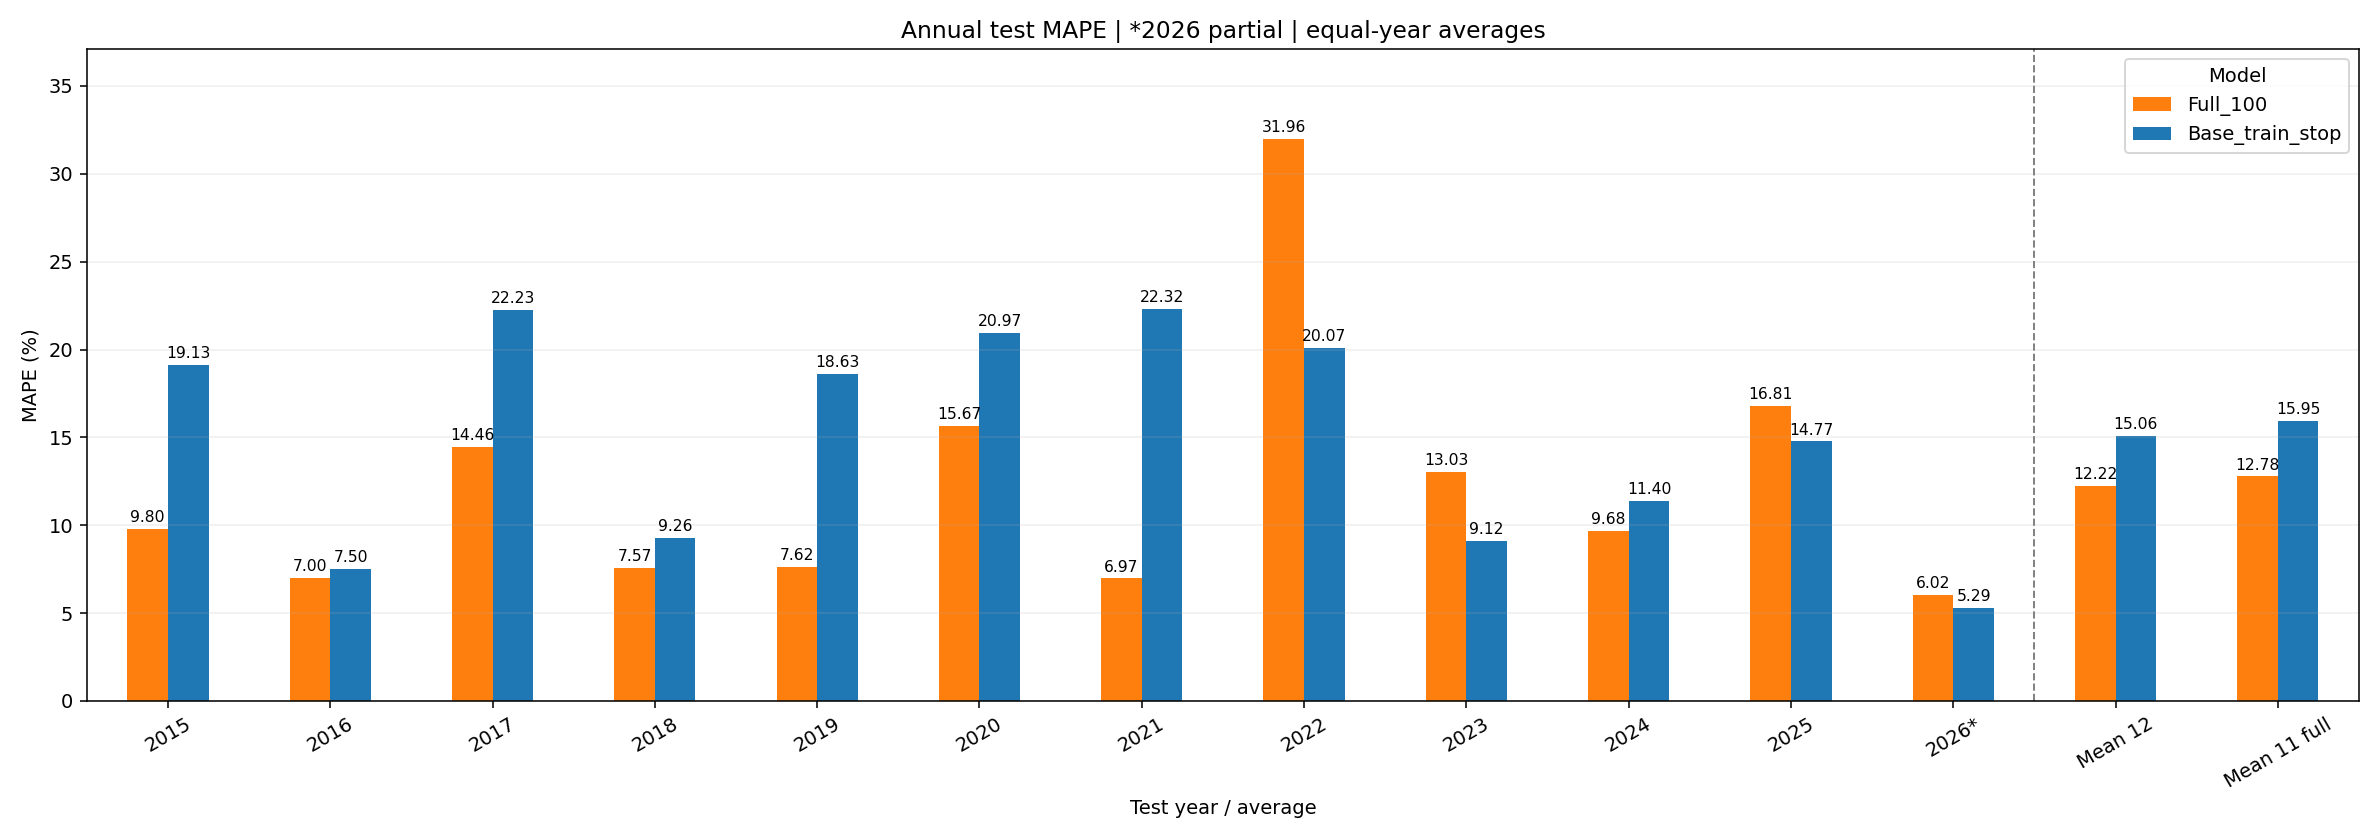

In [3]:
annual=metrics[metrics.Split=='Test'].pivot(index='Year',columns='Model',values='MAPE')[['Full_100','Base_train_stop']]
annual['Base_minus_full_pp']=annual.Base_train_stop-annual.Full_100
display(annual.round(4))
cols=['Full_100','Base_train_stop']
means=pd.DataFrame({'Mean_2015_2026':annual[cols].mean(),'Mean_2015_2025':annual.loc[2015:2025,cols].mean()}).T
means['Base_minus_full_pp']=means.Base_train_stop-means.Full_100
display(means.round(4))
annual.to_csv(OUT/'annual_test_mape.csv');means.to_csv(OUT/'mean_test_mape.csv')
chart=annual[cols].copy();chart.index=[str(y)+('*' if y==2026 else '') for y in chart.index]
chart.loc['Mean 12']=means.loc['Mean_2015_2026',cols]
chart.loc['Mean 11 full']=means.loc['Mean_2015_2025',cols]
ax=chart.plot.bar(figsize=(17,6),rot=30,color=['tab:orange','tab:blue'])
ax.set(title='Annual test MAPE | *2026 partial | equal-year averages',xlabel='Test year / average',ylabel='MAPE (%)')
ax.axvline(11.5,color='gray',ls='--',lw=1)
for container in ax.containers:ax.bar_label(container,fmt='%.2f',padding=2,fontsize=8)
ax.margins(y=.16);ax.grid(axis='y',alpha=.2)
plt.tight_layout();plt.savefig(OUT/'annual_test_mape.png',dpi=140);plt.show()
wins=int((annual.Base_minus_full_pp<0).sum())
print(f'基准停训方案在{wins}/12年MAPE更低。')
for label,row in means.iterrows():print(f'{label}: 全涨幅100轮{row.Full_100:.4f}%，基准停训{row.Base_train_stop:.4f}%，差值{row.Base_minus_full_pp:+.4f}个百分点。')


## 基准各年的训练停止位置
这里显示停止规则的执行情况，不以测试误差选训练轮数。

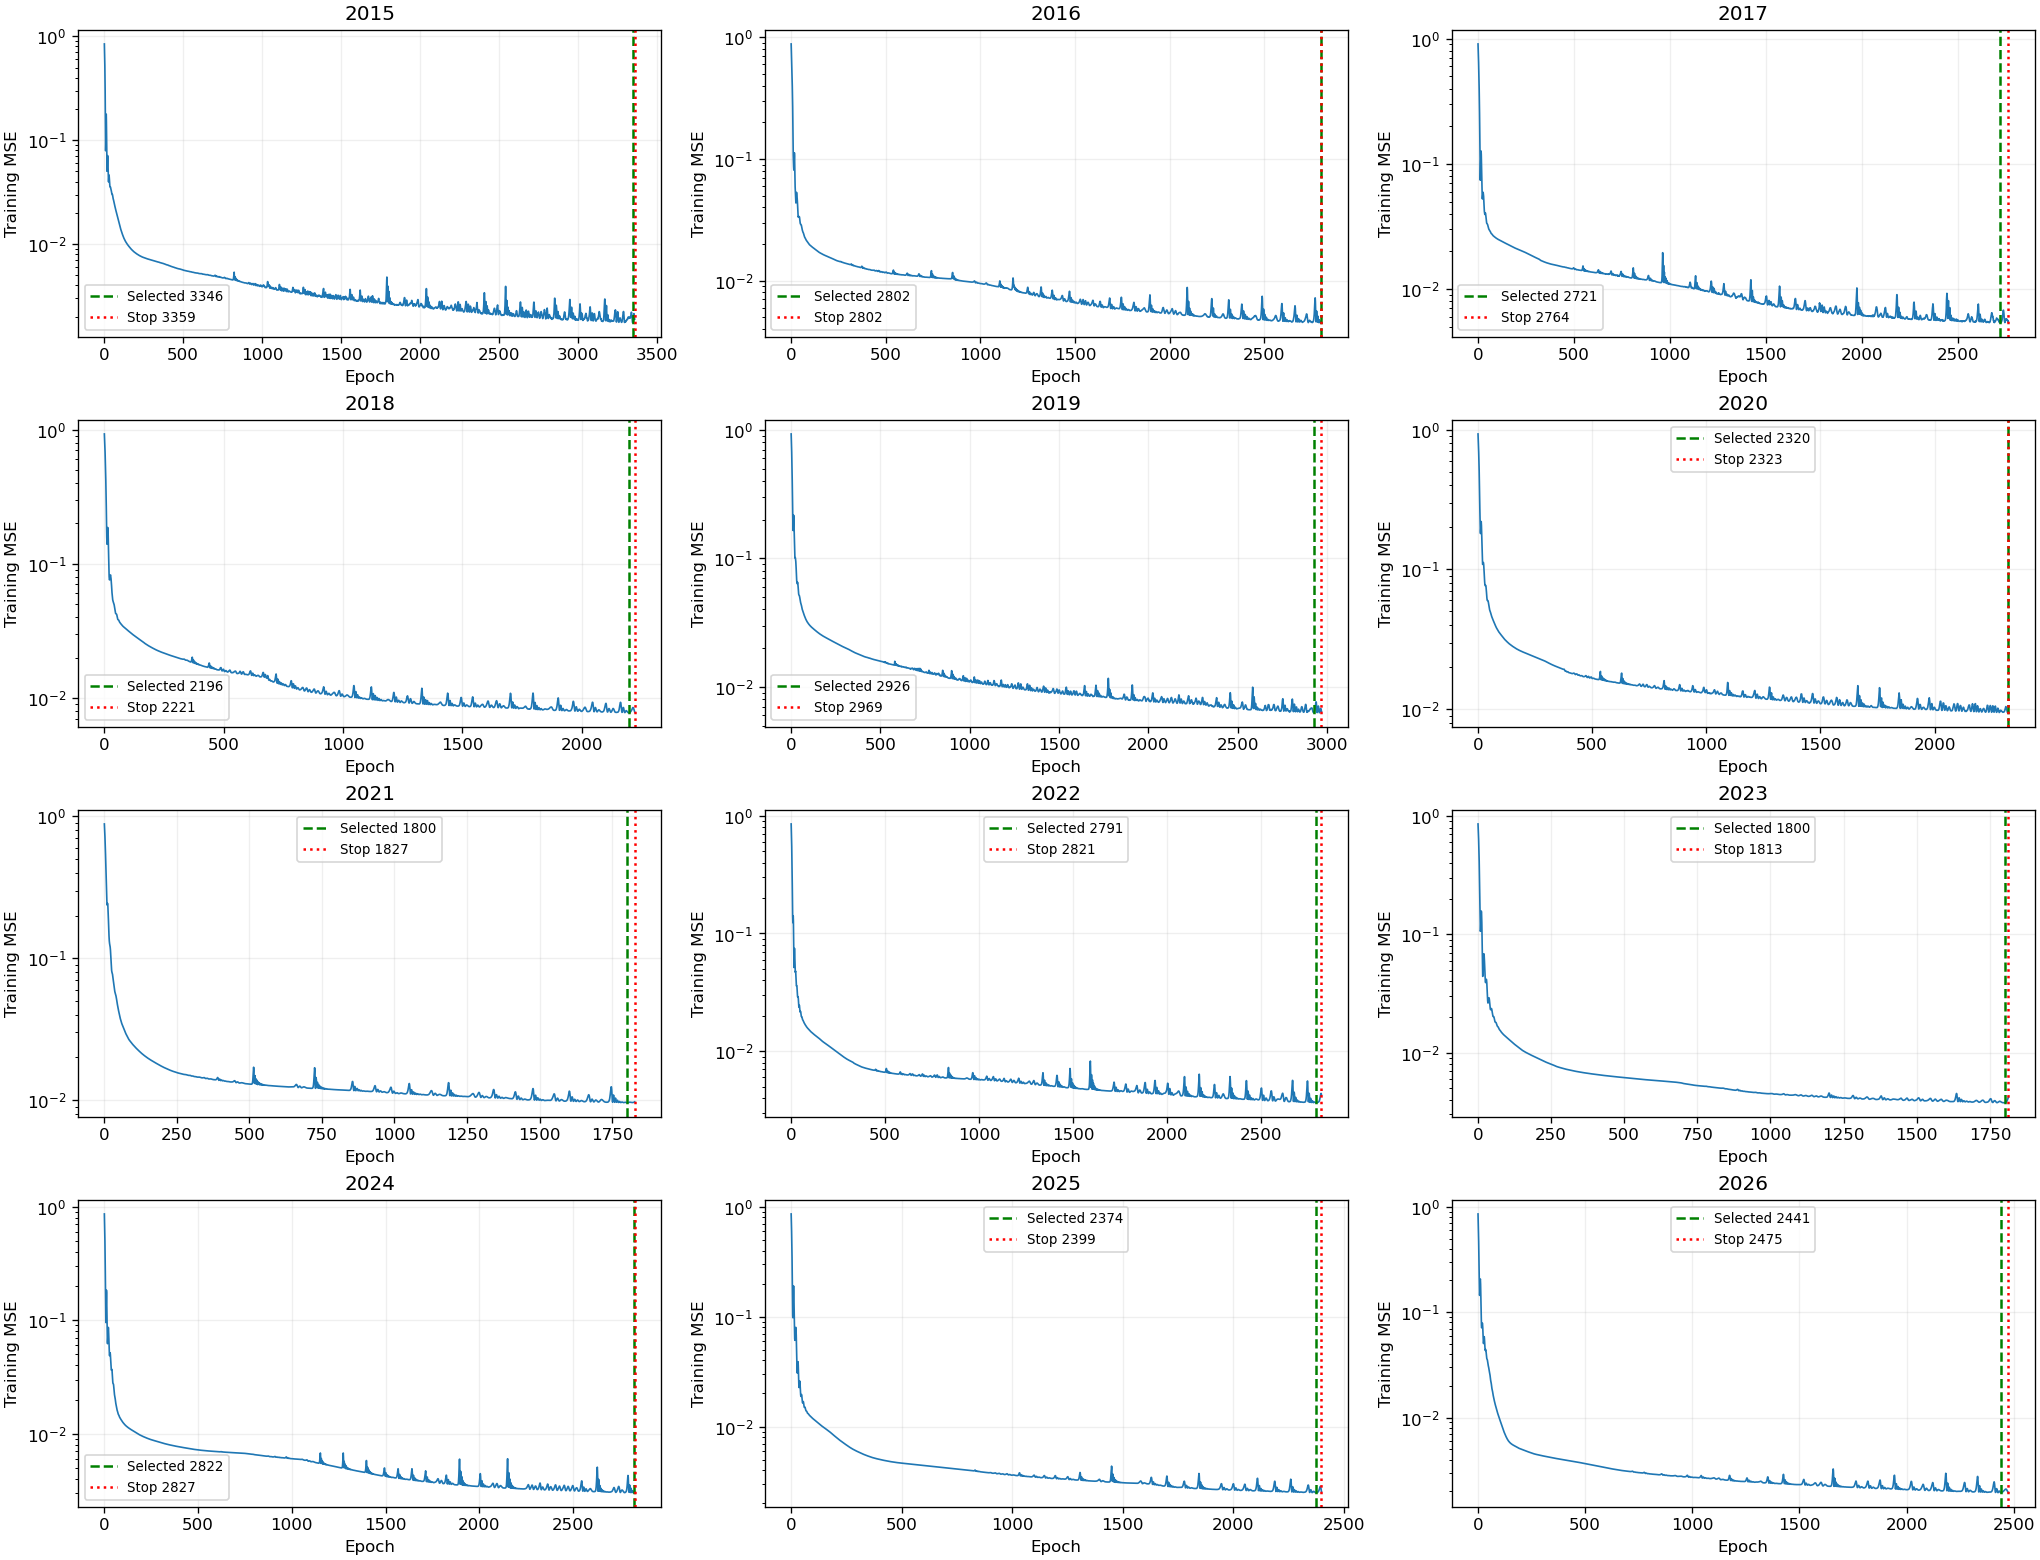

In [4]:
fig,axes=plt.subplots(4,3,figsize=(17,13),constrained_layout=True)
for ax,year in zip(axes.flat,YEARS):
    h=history[(history.Year==year)&(history.Model=='Base_train_stop')]
    s=selection[(selection.Year==year)&(selection.Model=='Base_train_stop')].iloc[0]
    ax.plot(h.Epoch,h.MSE_standardized,lw=1)
    ax.axvline(s.Selected_epoch,color='green',ls='--',label=f'Selected {s.Selected_epoch}')
    ax.axvline(s.Stop_epoch,color='red',ls=':',label=f'Stop {s.Stop_epoch}')
    ax.set(title=str(year),yscale='log',xlabel='Epoch',ylabel='Training MSE');ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.savefig(OUT/'base_annual_convergence.png',dpi=120);plt.show()


## 本次逐年比较结论

2015—2026年度等权平均测试MAPE：金铜5＋20日固定100轮为 **12.2155%**，基准按训练MSE停训为 **15.0570%**；全涨幅100轮低 **2.8415个百分点**，在 **8/12年** 更好。

仅统计2015—2025完整11年，均值分别为12.7785%和15.9452%，方向一致。2026年截至2026-07-23，基准5.2873%优于全涨幅100轮6.0224%，但不能把该年的优势推广到全部时期。基准更好的年份为2022、2023、2025、2026。

全部基准年度模型均满足指定停止规则，没有触及10000轮上限。2026结果与上一节精确复现。均值包含2022年，没有根据结果剔除年份。

本次支持“全涨幅100轮方案在这批年度测试中的整体MAPE更低”，不能单独认定是额外变量有效还是较少训练产生了正则化作用，因为两组同时改变了特征与训练规则；也不能仅凭此证明某个方案发生过拟合。

在大多数情况下,即使有了22年极差的表现,但是采用了更多信息的模型依旧平均表现更好一点.

# 全模型逐年比较：固定100轮 vs 训练MSE停训

两组完全相同：原7个水平变量＋金铜各5/20条记录涨幅，共11输入，ReLU、隐藏层16/32、线性输出、Adam学习率0.01、全批量、seed42，无时间变量。同一年使用同一初始化、同一训练路径，保存第100轮权重后继续训练，隔离训练时长及权重选择规则的差异。

Full_100固定第100轮；Full_train_stop在训练MSE连续100轮未比上次有效改善基准下降至少1%时停止，恢复训练MSE最低的权重，最多10000轮。停训只看训练数据，不看测试MAPE。“满足停训规则”不等于全局最优。

逐年测试2015—2026，每次只用测试年前的数据训练及拟合标准化器。两组统一去除计算涨幅所需前20条记录。MAPE按年计算后等权平均，保留2022，2026为部分年度；另列2015—2025完整年度平均。沿用原同日目标，不更改为未来收益率预测。

为诊断过拟合，同时保留训练MAPE。相同模型继续训练后若训练误差下降、测试误差上升，支持该年存在泛化恶化；仍需注意分布变化与随机初始化。本次固定seed42，不据测试误差选择轮数。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_FULL_ANNUAL_OUT',str(ROOT/'results/mlp_full_annual_comparison_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}

YEARS=list(range(2015,2027))
REL_MIN_DELTA,PATIENCE,MAX_EPOCHS=.01,100,10000
COLS=BASE+['gold_5','gold_20','copper_5','copper_20']
GROUPS={'Full_100':COLS,'Full_train_stop':COLS}
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'years':YEARS,'seed':SEED,'lr':LR,'groups':GROUPS,'relative_min_delta':REL_MIN_DELTA,'patience':PATIENCE,'max_epochs':MAX_EPOCHS,
    'data_end':str(x.index.max()),'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
print('数据截止：',x.index.max(),'；2026按已有记录统计。')


数据截止： 2026-07-23 00:00:00 ；2026按已有记录统计。


In [2]:
metric_rows,selection_rows,split_rows,history_frames,pred_frames=[],[],[],[],[]
for year in YEARS:
    tr=x.index[x.index.year<year];te=x.index[x.index.year==year]
    assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
    for split,idx in [('Train',tr),('Test',te)]:
        split_rows.append({'Year':year,'Split':split,'N':len(idx),'Start':str(idx.min().date()),'End':str(idx.max().date())})
    sy=StandardScaler().fit(y.loc[tr].to_numpy().reshape(-1,1))
    yt=tensor(sy.transform(y.loc[tr].to_numpy().reshape(-1,1)))
    sx=StandardScaler().fit(x.loc[tr,COLS]);xt=tensor(sx.transform(x.loc[tr,COLS]))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    reference,best_loss=float('inf'),float('inf');waiting,best_epoch=0,0;history=[];state100=None
    for epoch in range(1,MAX_EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():current=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(current)
        if current<best_loss:best_loss,best_epoch,best_state=current,epoch,deepcopy(model.state_dict())
        if current<=reference*(1-REL_MIN_DELTA):reference,waiting=current,0
        else:waiting+=1
        history.append({'Year':year,'Epoch':epoch,'MSE_standardized':current,'Waiting':waiting})
        if epoch==100:state100=deepcopy(model.state_dict())
        if waiting>=PATIENCE:break
    assert state100 is not None
    reason='plateau_1pct_100epochs' if waiting>=PATIENCE else 'max_epochs'
    history_frames.append(pd.DataFrame(history))
    for name,state,selected_epoch in [('Full_100',state100,100),('Full_train_stop',best_state,best_epoch)]:
        model.load_state_dict(state);model.eval()
        with torch.no_grad():selected_mse=((model(xt)-yt)**2).mean().item()
        if name=='Full_train_stop':assert np.isclose(selected_mse,best_loss,rtol=1e-6)
        selection_rows.append({'Year':year,'Model':name,'Selected_epoch':selected_epoch,
            'Stop_epoch':100 if name=='Full_100' else epoch,
            'Stop_reason':'fixed_100' if name=='Full_100' else reason,'Selected_train_MSE':selected_mse})
        for split,idx in [('Train',tr),('Test',te)]:
            with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,COLS]))).numpy()).ravel()
            truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            assert np.isfinite(pred).all()
            metric_rows.append({'Year':year,'Model':name,'Split':split,'N':len(idx),'MAPE':np.abs(pe).mean(),'MPE':pe.mean()})
            pred_frames.append(pd.DataFrame({'Date':idx,'Year':year,'Model':name,'Split':split,'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
        torch.save({'state_dict':state,'features':COLS,'year':year,'seed':SEED,'selected_epoch':selected_epoch,
            'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},OUT/f'{year}_{name}.pt')
    print(f'{year}: best={best_epoch}, stop={epoch}, {reason}',flush=True)
metrics=pd.DataFrame(metric_rows);selection=pd.DataFrame(selection_rows);splits=pd.DataFrame(split_rows)
history=pd.concat(history_frames,ignore_index=True);predictions=pd.concat(pred_frames,ignore_index=True)
for key,frame in [('metrics',metrics),('selection',selection),('splits',splits),('training_history',history),('predictions',predictions)]:
    frame.to_csv(OUT/f'{key}.csv',index=False)
display(splits[splits.Split=='Test']);display(selection)
if (selection.Stop_reason=='max_epochs').any(): print('注意：部分年份触及上限，不能称为满足停训条件。')


2015: best=3630, stop=3649, plateau_1pct_100epochs
2016: best=3442, stop=3451, plateau_1pct_100epochs
2017: best=1886, stop=1895, plateau_1pct_100epochs
2018: best=2964, stop=3014, plateau_1pct_100epochs
2019: best=3391, stop=3420, plateau_1pct_100epochs
2020: best=2027, stop=2078, plateau_1pct_100epochs
2021: best=2124, stop=2124, plateau_1pct_100epochs
2022: best=3164, stop=3187, plateau_1pct_100epochs
2023: best=2605, stop=2620, plateau_1pct_100epochs
2024: best=2602, stop=2607, plateau_1pct_100epochs
2025: best=2261, stop=2281, plateau_1pct_100epochs
2026: best=2019, stop=2044, plateau_1pct_100epochs


,Year,Split,N,Start,End
1,2015,Test,266,2015-01-01,2015-12-31
3,2016,Test,268,2016-01-01,2016-12-31
5,2017,Test,267,2017-01-02,2017-12-31
7,2018,Test,269,2018-01-01,2018-12-31
9,2019,Test,271,2019-01-01,2019-12-31
11,2020,Test,271,2020-01-01,2020-12-31
13,2021,Test,272,2021-01-01,2021-12-31
15,2022,Test,274,2022-01-03,2022-12-31
17,2023,Test,273,2023-01-02,2023-12-31
19,2024,Test,273,2024-01-01,2024-12-31


,Year,Model,Selected_epoch,Stop_epoch,Stop_reason,Selected_train_MSE
0,2015,Full_100,100,100,fixed_100,0.012847
1,2015,Full_train_stop,3630,3649,plateau_1pct_100epochs,0.001169
2,2016,Full_100,100,100,fixed_100,0.013924
3,2016,Full_train_stop,3442,3451,plateau_1pct_100epochs,0.001452
4,2017,Full_100,100,100,fixed_100,0.019287
5,2017,Full_train_stop,1886,1895,plateau_1pct_100epochs,0.003487
6,2018,Full_100,100,100,fixed_100,0.022851
7,2018,Full_train_stop,2964,3014,plateau_1pct_100epochs,0.003430
8,2019,Full_100,100,100,fixed_100,0.032635
9,2019,Full_train_stop,3391,3420,plateau_1pct_100epochs,0.004603


## 逐年MAPE、平均值与柱状图
差值为停训模型减100轮模型，正值表示延长训练后更差。训练和测试分别展示，均值按年份等权计算。

测试MAPE：
年度等权平均：
训练MAPE：
延长训练在3/12年降低测试MAPE。
9/12年出现训练MAPE降低而测试MAPE升高。


Model,Full_100,Full_train_stop,Stop_minus_100_pp
Year,,,
2015,9.7961,14.9804,5.1843
2016,7.0006,8.5638,1.5632
2017,14.4632,17.4597,2.9965
2018,7.5655,9.1422,1.5767
2019,7.6198,8.5072,0.8875
2020,15.6667,38.8419,23.1751
2021,6.9679,35.8320,28.8641
2022,31.9622,42.4284,10.4662
2023,13.0325,12.9793,-0.0532


Model,Full_100,Full_train_stop,Stop_minus_100_pp
Mean_2015_2026,12.2155,18.2007,5.9851
Mean_2015_2025,12.7785,18.9970,6.2184


Model,Full_100,Full_train_stop,Stop_minus_100_pp
Year,,,
2015,2.0063,0.5705,-1.4358
2016,2.3980,0.8577,-1.5404
2017,2.4484,1.1214,-1.3270
2018,2.6375,1.0429,-1.5946
2019,2.8309,1.1371,-1.6938
2020,2.9579,1.2981,-1.6597
2021,3.4055,1.5636,-1.8419
2022,4.4678,1.6964,-2.7714
2023,4.6707,1.8035,-2.8672


,Train_MAPE_change_pp,Test_MAPE_change_pp,Train_better_test_worse
Year,,,
2015,-1.4358,5.1843,True
2016,-1.5404,1.5632,True
2017,-1.3270,2.9965,True
2018,-1.5946,1.5767,True
2019,-1.6938,0.8875,True
2020,-1.6597,23.1751,True
2021,-1.8419,28.8641,True
2022,-2.7714,10.4662,True
2023,-2.8672,-0.0532,False


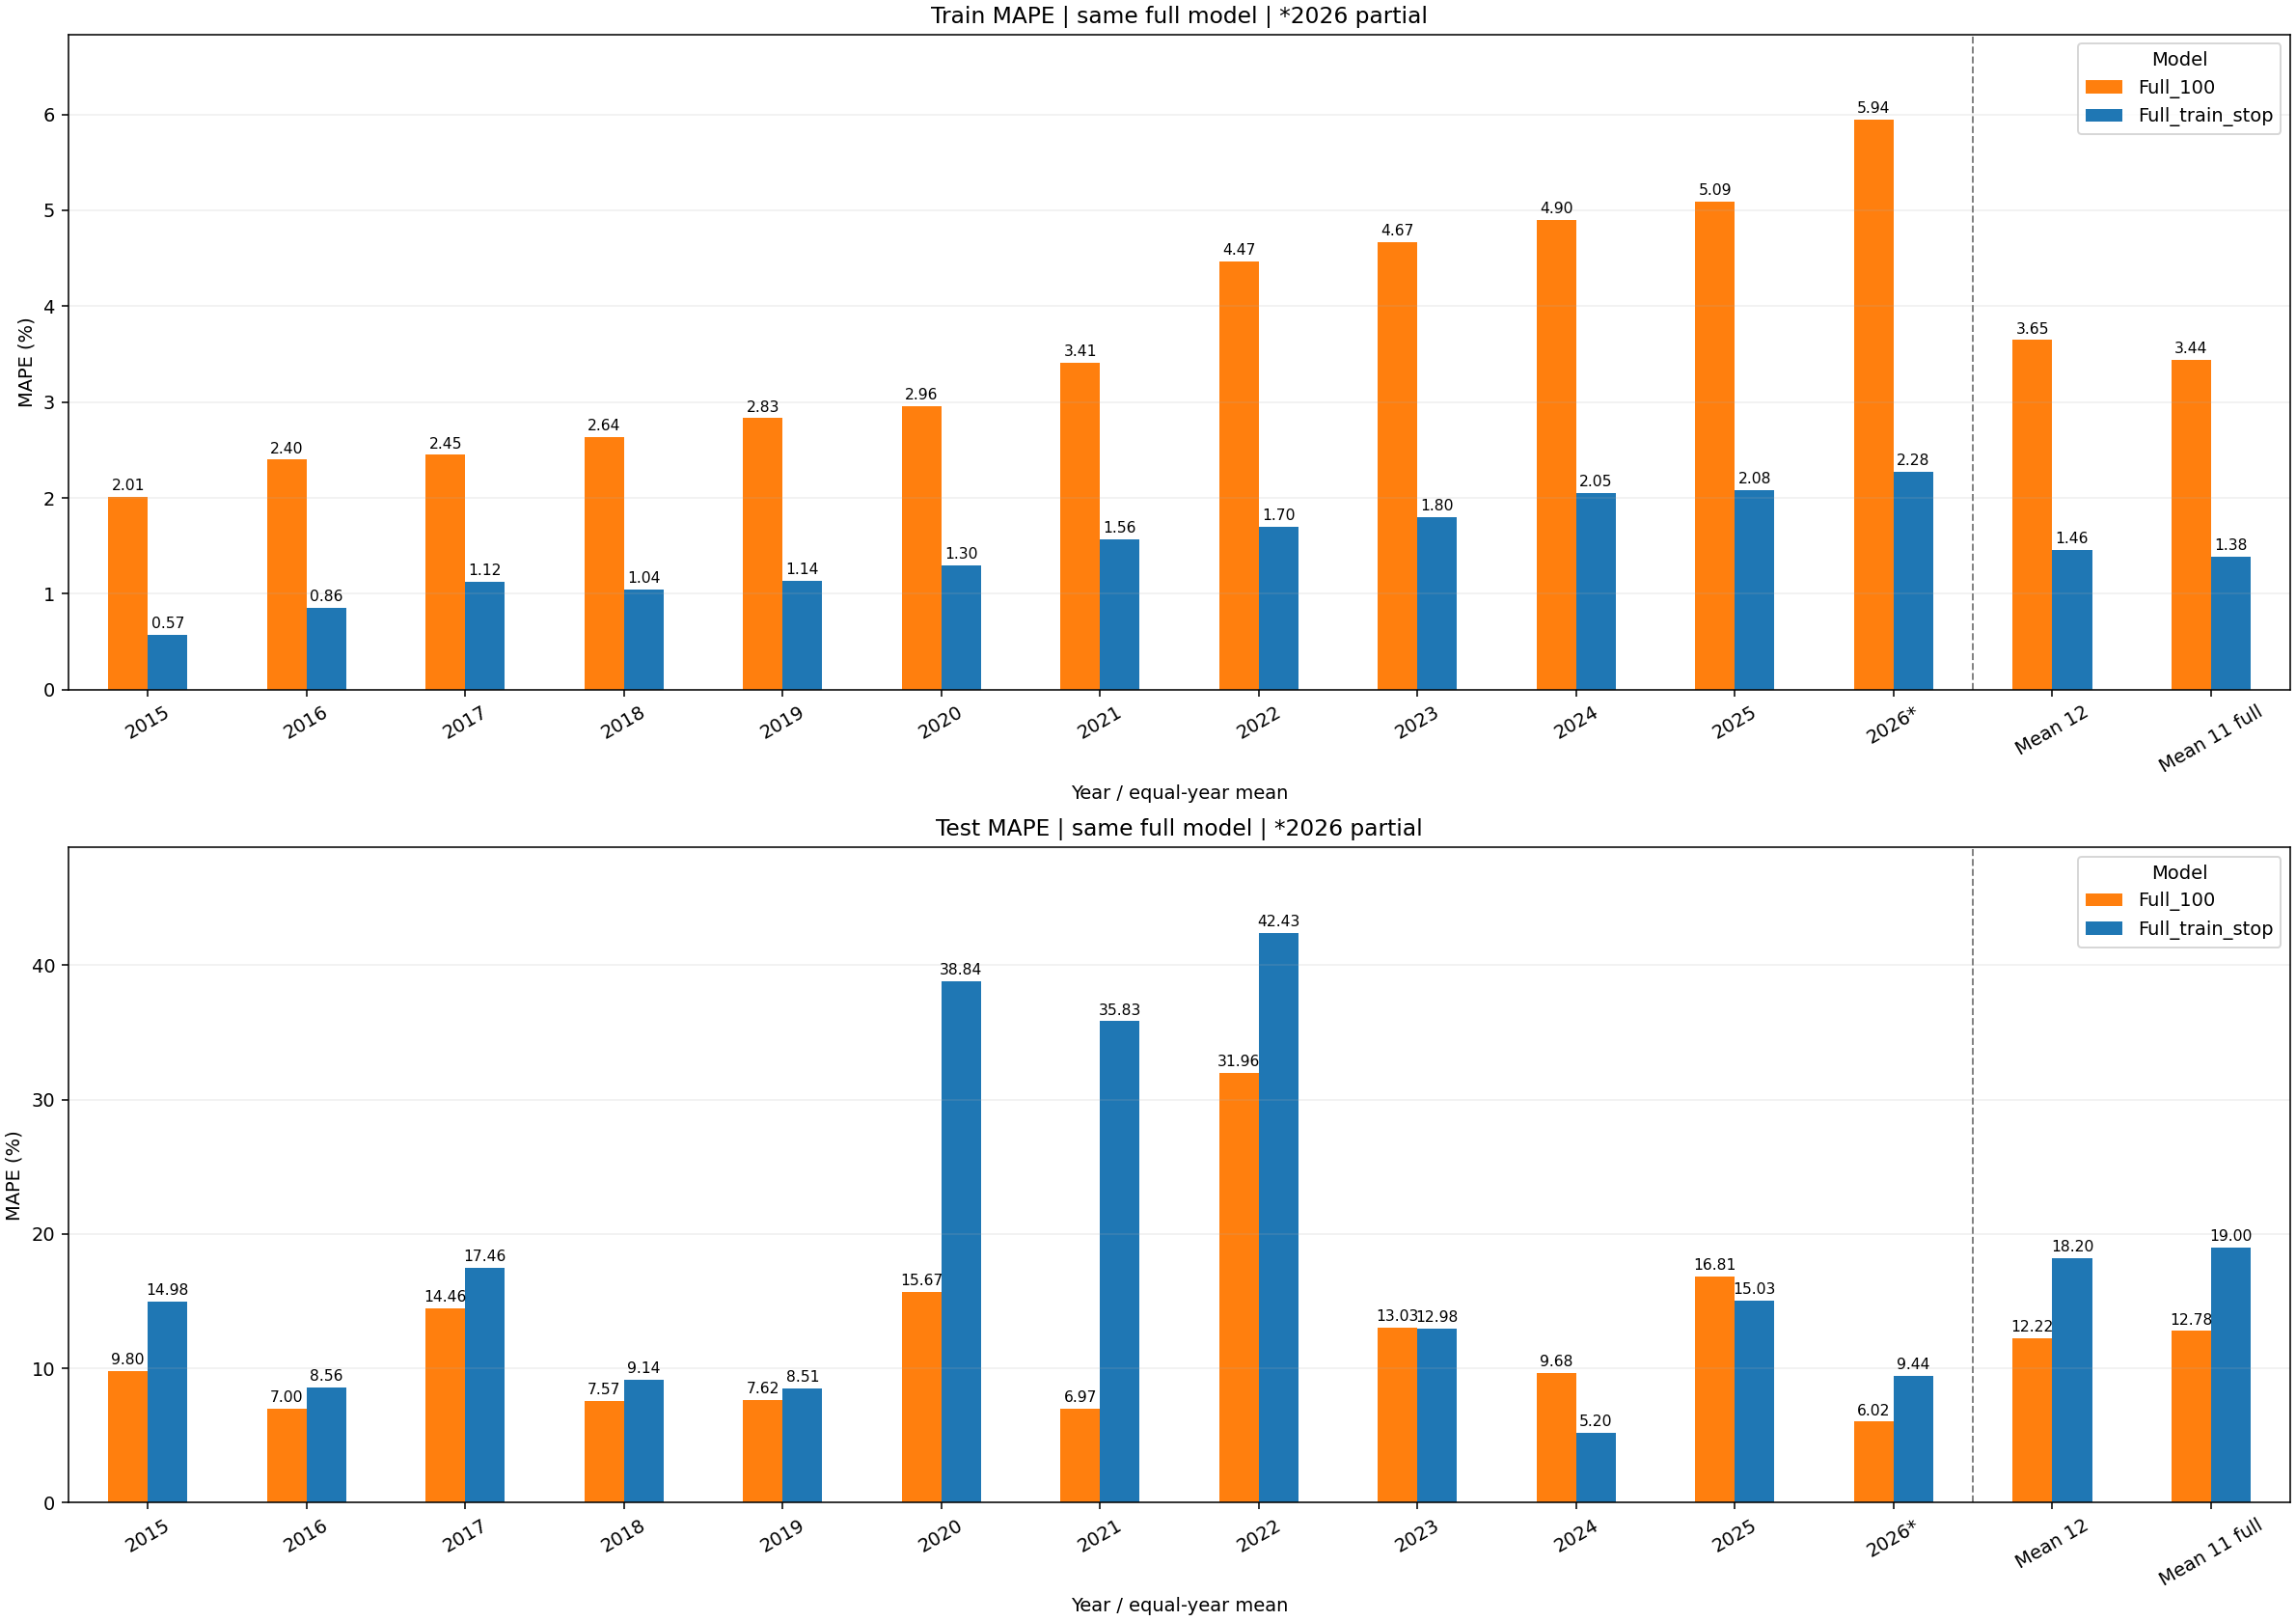

In [3]:
cols=['Full_100','Full_train_stop']
annual=metrics[metrics.Split=='Test'].pivot(index='Year',columns='Model',values='MAPE')[cols]
annual['Stop_minus_100_pp']=annual.Full_train_stop-annual.Full_100
train=metrics[metrics.Split=='Train'].pivot(index='Year',columns='Model',values='MAPE')[cols]
train['Stop_minus_100_pp']=train.Full_train_stop-train.Full_100
means=pd.DataFrame({'Mean_2015_2026':annual[cols].mean(),'Mean_2015_2025':annual.loc[2015:2025,cols].mean()}).T
means['Stop_minus_100_pp']=means.Full_train_stop-means.Full_100
print('测试MAPE：');display(annual.round(4));print('年度等权平均：');display(means.round(4));print('训练MAPE：');display(train.round(4))
annual.to_csv(OUT/'annual_test_mape.csv');means.to_csv(OUT/'mean_test_mape.csv');train.to_csv(OUT/'annual_train_mape.csv')
fig,axes=plt.subplots(2,1,figsize=(17,12),constrained_layout=True)
for ax,frame,label in [(axes[0],train,'Train'),(axes[1],annual,'Test')]:
    chart=frame[cols].copy();chart.index=[str(y)+('*' if y==2026 else '') for y in chart.index]
    chart.loc['Mean 12']=frame[cols].mean();chart.loc['Mean 11 full']=frame.loc[2015:2025,cols].mean()
    chart.plot.bar(ax=ax,rot=30,color=['tab:orange','tab:blue'])
    ax.set(title=f'{label} MAPE | same full model | *2026 partial',xlabel='Year / equal-year mean',ylabel='MAPE (%)')
    ax.axvline(11.5,color='gray',ls='--',lw=1)
    for container in ax.containers:ax.bar_label(container,fmt='%.2f',padding=2,fontsize=8)
    ax.margins(y=.15);ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'annual_mape.png',dpi=140);plt.show()
diagnosis=pd.DataFrame({'Train_MAPE_change_pp':train.Stop_minus_100_pp,'Test_MAPE_change_pp':annual.Stop_minus_100_pp})
diagnosis['Train_better_test_worse']=(diagnosis.Train_MAPE_change_pp<0)&(diagnosis.Test_MAPE_change_pp>0)
diagnosis.to_csv(OUT/'generalization_diagnostics.csv');display(diagnosis.round(4))
print(f'延长训练在{int((annual.Stop_minus_100_pp<0).sum())}/12年降低测试MAPE。')
print(f'{int(diagnosis.Train_better_test_worse.sum())}/12年出现训练MAPE降低而测试MAPE升高。')


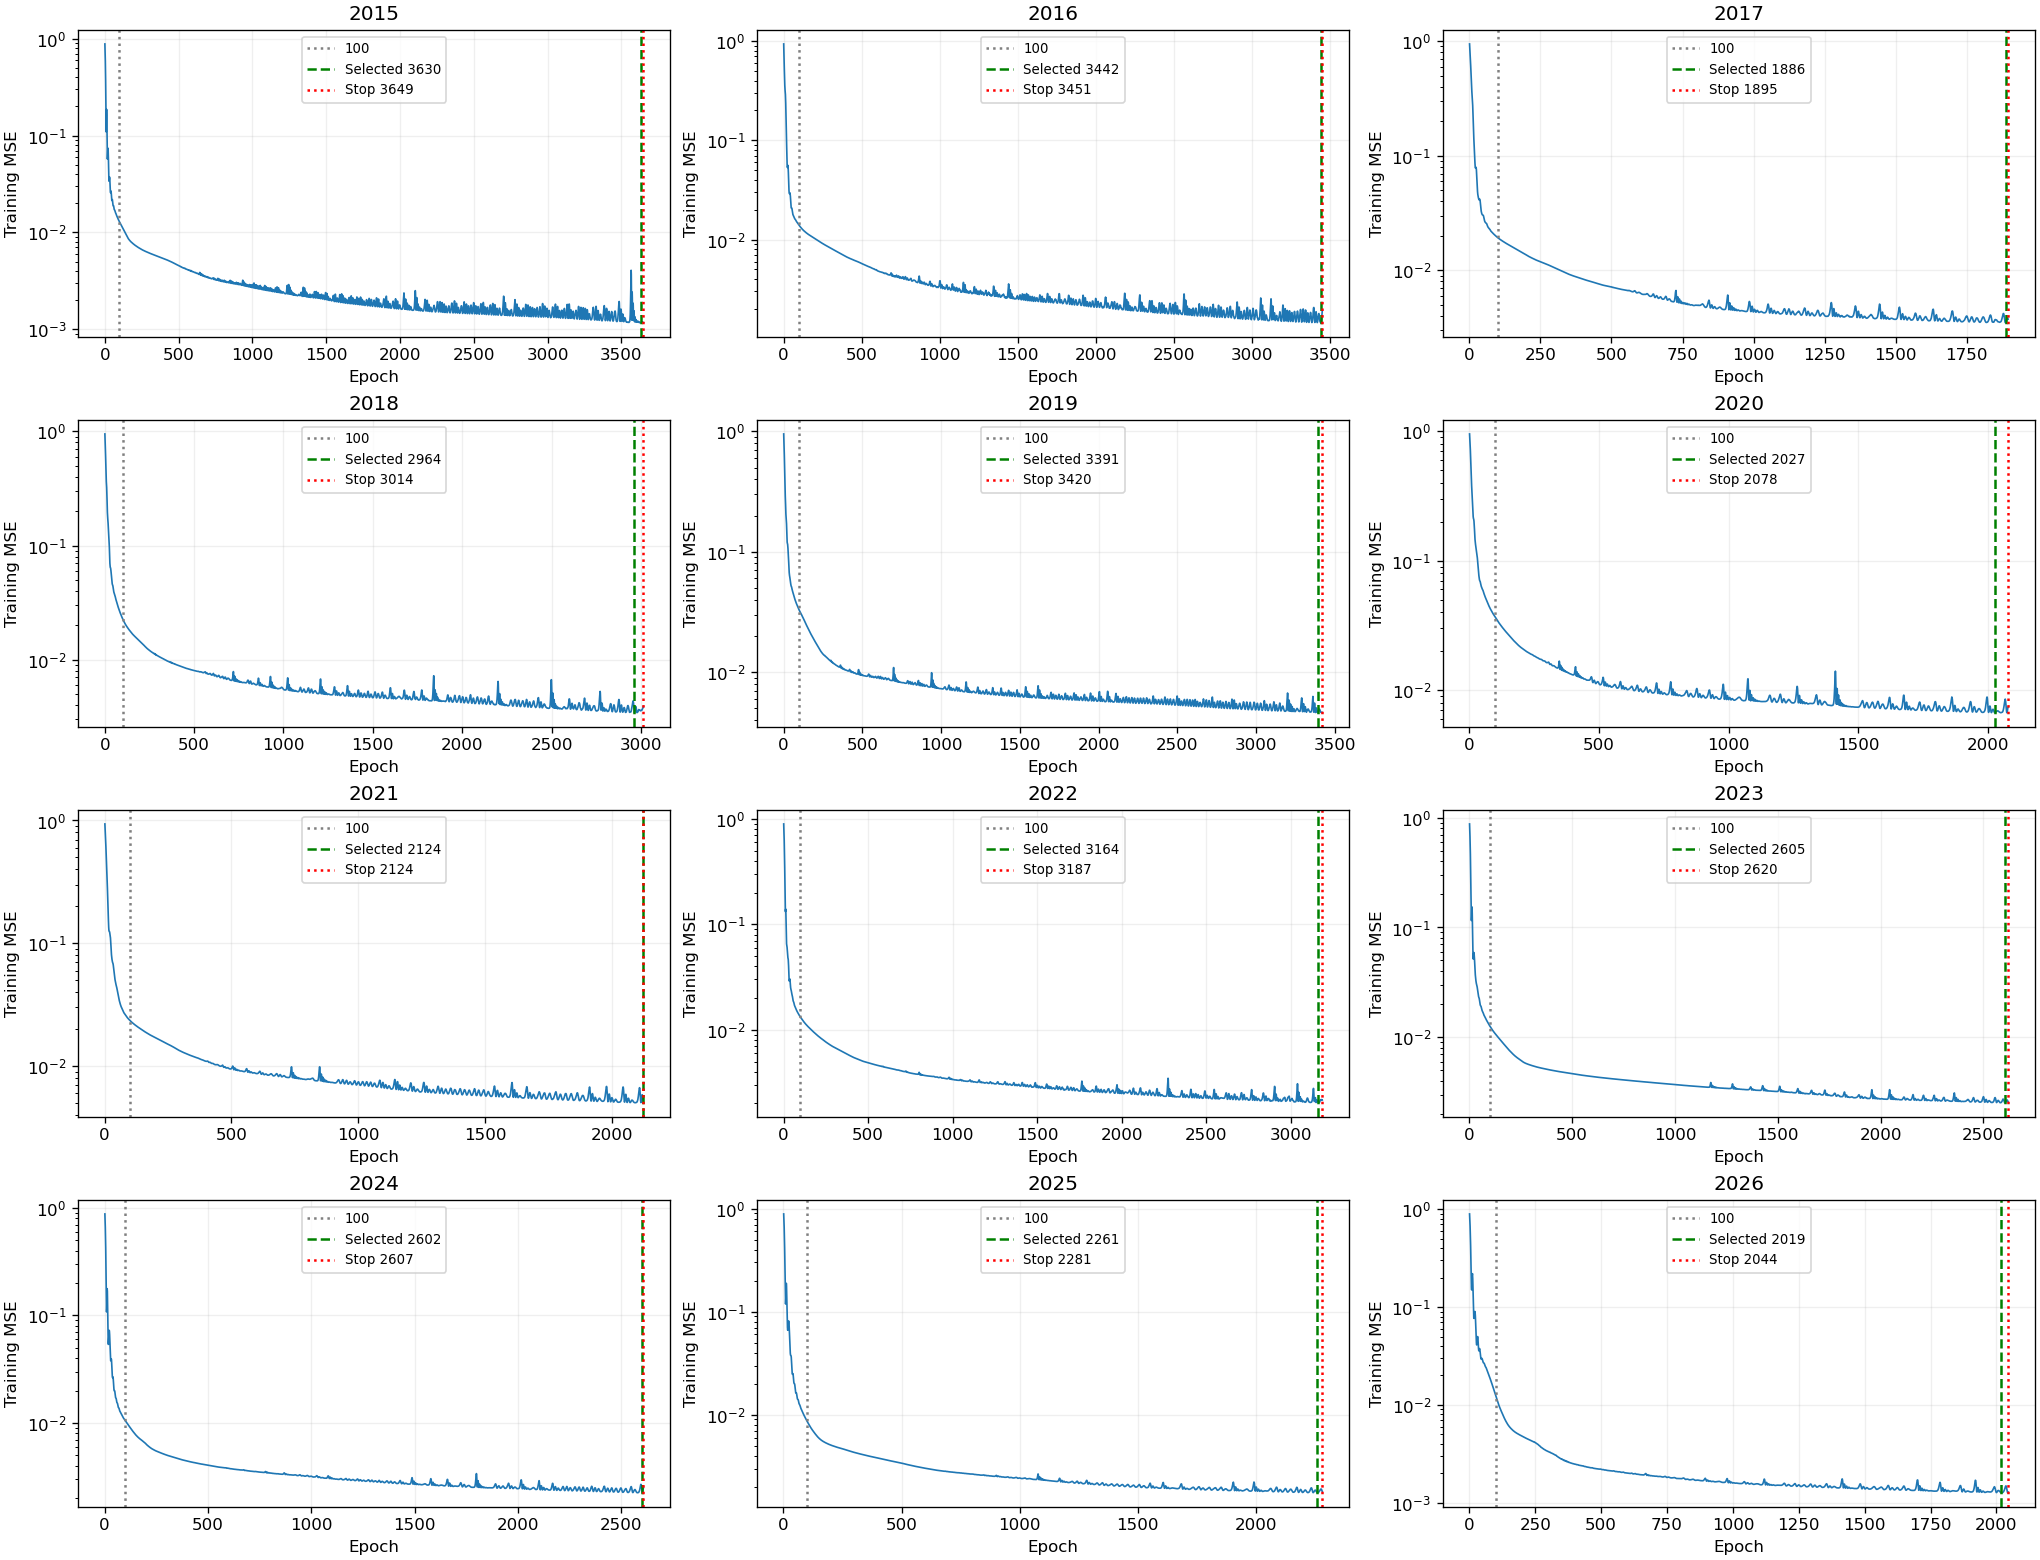

In [4]:
fig,axes=plt.subplots(4,3,figsize=(17,13),constrained_layout=True)
for ax,year in zip(axes.flat,YEARS):
    h=history[history.Year==year];s=selection[(selection.Year==year)&(selection.Model=='Full_train_stop')].iloc[0]
    ax.plot(h.Epoch,h.MSE_standardized,lw=1)
    ax.axvline(100,color='gray',ls=':',label='100')
    ax.axvline(s.Selected_epoch,color='green',ls='--',label=f'Selected {s.Selected_epoch}')
    ax.axvline(s.Stop_epoch,color='red',ls=':',label=f'Stop {s.Stop_epoch}')
    ax.set(title=str(year),yscale='log',xlabel='Epoch',ylabel='Training MSE');ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.savefig(OUT/'full_annual_convergence.png',dpi=120);plt.show()


## 同一全模型的逐年结论

2015—2026年度等权平均测试MAPE：固定100轮 **12.2155%**，按训练MSE停止 **18.2007%**，延长训练增加 **5.9851个百分点**。2015—2025完整11年均值分别12.7785%和18.9970%，方向一致。2022保留，2026截至7月23日。

全部12年训练MAPE都下降，但9/12年测试MAPE上升；改善的测试年只有2023、2024、2025，其中2023改善仅0.0532个百分点。2020从15.6667%升至38.8419%，2021从6.9679%升至35.8320%。

两组保持相同特征、初始化和训练路径，仅改变训练时长及权重选择；因此本轮比此前“全模型100轮 vs 基准停训”更直接支持：持续优化训练误差在多数年份损害了泛化，表现出过拟合迹象。它不证明100轮是最佳轮数，也不能单独区分历史噪声拟合与分布变化下的外推恶化。后续应以训练年份内的时间验证段选择轮数，避免根据这些已查看的年度测试结果追选轮数。

全部年度达到规定停止条件，没有触及10000轮上限；100轮结果逐年与上一节一致，2026延长训练结果与前面的10组实验一致。

根据测试的结论,当信息更多,训练次数更多的时候,我们会学到更多的噪声.  
充分训练的情况下,脱离基本面的信息,如金与铜的波动,反而会被放大.